# Wstęp Teoretyczny: Architektura i Przełom AlexNet

Przed uruchomieniem kodu i rozpoczęciem trenowania modelu warto zrozumieć, dlaczego **AlexNet** (zaprojektowany w 2012 roku przez Alexa Krizhevsky'ego, Ilyę Sutskevera i Geoffreya Hintona) stał się kamieniem milowym w rozwoju sztucznej inteligencji. Model ten zdominował konkurs **ILSVRC-2012 (ImageNet)** , zapoczątkowując erę nowoczesnego głębokiego uczenia (*Deep Learning*).

---

##1. Co przyniosły nowoczesne sieci konwolucyjne (CNN)?
* **Automatyczna ekstrakcja cech:** Zamiast ręcznie opisywać wygląd obiektu, sieci podaje się miliony zdjęć, a ona samodzielnie uczy się uogólniać jego kluczowe cechy.
* **Hierarchia cech:** Sieć składa się z kilku warstw konwolucyjnych. Każda warstwa posiada wiele filtrów, co pozwala patrzeć na obraz z różnych perspektyw i dostrzegać inne aspekty:
  * Warstwy początkowe skupiają się na detekcji podstawowych krawędzi i linii.
  * Warstwy środkowe łączą je w rogi i tekstury.
  * Warstwy głębokie rozpoznają całe części obiektów lub gotowe przedmioty.

###1.1 Jak działa konwolucja
Konwolucja (splot) to operacja służąca do **automatycznej ekstrakcji cech** z obrazu. Proces ten polega na przesuwaniu małej macierzy wag, zwanej **filtrem** lub maską, nad obrazem wejściowym.

![Konwolucja](https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEhKADjuZRZ3QZQo6LC5YBrnKK4d66SenZBX3d-yOkg1OW70SwwDLVCAAs_Gy6ugR5XukZrcaQ87fixb2nZt4LXRsXbWhugcOrKRyvqTQLXretKpYkWlua3lfXhgV8yzods73TUcSWQvSpFe/s400/Przechwytywanie.PNG)
*   **Mechanizm:** Filtr mnoży wartości pikseli przez swoje wagi, a wyniki są sumowane, tworząc tzw. mapę cech[cite: 1].
*   **Cel:** W zależności od wag filtra, sieć uczy się wykrywać konkretne wzorce, takie jak pionowe lub poziome krawędzie, narożniki czy tekstury[cite: 1].
*   **Krok (Stride):** Określa, o ile pikseli przesuwa się filtr w każdym kroku (np. w AlexNet w pierwszej warstwie stride wynosi 4)[cite: 1].

###1.2 Jak działa pooling
Pooling (podpróbkowanie) to operacja redukcji wymiarów map cech, która pozwala zachować najważniejsze informacje przy jednoczesnym zmniejszeniu liczby parametrów obliczeniowych[cite: 1].

![Pooling](https://miro.medium.com/v2/resize:fit:640/format:webp/1*OxhPzQ9gzPBkKNcAE_nLMg.jpeg)

*   **Max Pooling:** Najpopularniejsza metoda (stosowana w AlexNet), polegająca na wybraniu maksymalnej wartości z danego okna (np. $2 \times 2$ lub $3 \times 3$).
*   **W AlexNet:** Zastosowano unikalny **Overlapping Pooling**, gdzie rozmiar okna ($3 \times 3$) jest większy niż krok ($2$), co pomaga dodatkowo zredukować błąd i zapobiega nadmiernemu dopasowaniu.

---

## 2. Architektura sieci AlexNet

AlexNet składa się z **5 warstw konwolucyjnych (Conv)** oraz **3 warstw w pełni połączonych (Fully Connected - FC)**. Warstwy poolingu (Pooling) służą do zachowania najsilniejszych cech, ale nie są liczone jako osobne warstwy, ponieważ nie posiadają parametrów, które można wytrenować.

### Szczegółowy podział warstw i wymiarów:
1. **Input:** Obraz wyjściowy o wymiarach $227 \times 227 \times 3$ (kanały RGB).
2. **CONV 1:** Filtry $11 \times 11$, krok (stride) $= 4$, 96 filtrów (kernels). Wyjściowy rozmiar mapy cech to $55 \times 55$. Po niej następuje nakładający się (overlapping) **Max Pooling** o rozmiarze $3 \times 3$ i kroku $= 2$, który redukuje wymiar do $27 \times 27$.
3. **CONV 2:** Filtry $5 \times 5$ z dopełn. Ponownie zastosowano overlapping **Max Pooling** ($3 \times 3$, stride $= 2$), redukując rozmiar do $13 \times 13$.
4. **CONV 3 & CONV 4:** Filtry $3 \times 3$ z dopełnieniem (pad) $= 1$. Kolejno 384 i 384 filtry. Te warstwy są połączone bezpośrednio ze sobą, zachowując rozmiar $13 \times 13$.
5. **CONV 5:** Filtry $3 \times 3$, pad $= 1$, 256 filtrów. Wynik to nadal $13 \times 13$. Po tej warstwie następuje ostatni overlapping **Max Pooling** ($3 \times 3$, stride $= 2$), który spłaszcza przestrzeń do rozmiaru $6 \times 6$ przy 256 kanałach (łącznie 9216 cech).
6. **FC 1 & FC 2:** Dwie potężne warstwy w pełni połączone, każda posiadająca po **4096 neuronów**.
7. **FC 3 (Softmax):** Warstwa wyjściowa z **1000 neuronów** odpowiadająca klasyfikacji na tysiąc klas.

![Architektra AlexNet](https://media.licdn.com/dms/image/v2/C4D12AQEtAWq7HjBVEA/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1634438181465?e=2147483647&v=beta&t=vW0oEEbXoNiq-jL5_Tv0lA4HwZAsen_aZzFw7nXc9V0)

> **Uwaga sprzętowa:** Z powodu ograniczeń ówczesnych kart graficznych (mało pamięci VRAM), oryginalny model był celowo podzielony na **dwa niezależne procesory GPU**, które komunikowały się ze sobą tylko w określonych warstwach sieci. Współczesny sprzęt pozwala nam bez problemu uruchomić tę sieć w całości na jednym GPU.
![Architketura fizyczna](https://www.pinecone.io/_next/image/?url=https%3A%2F%2Fcdn.sanity.io%2Fimages%2Fvr8gru94%2Fproduction%2F511d51bd1d1ec3b7155250bf7e53cfa6cb52f215-1339x503.png&w=3840&q=75)

---

## 3. Trzy filary sukcesu – dlaczego to zadziałało?

Sam projekt warstw to za mało. Autorzy AlexNet wprowadzili kluczowe innowacje matematyczne i optymalizacyjne, które rozwiązały odwieczne problemy sieci neuronowych.

###A. Funkcja aktywacji ReLU (Rectified Linear Unit)
Wcześniej standardem były funkcje *Sigmoid* oraz *Tanh*, które "ściskały" wartości do przedziału $(0,1)$ lub $(-1,1)$. Ich największą wadą był **zanikający gradient** (ang. *vanishing gradient*) – przy dużych liczbach funkcja stawała się płaska, nachylenie wynosiło blisko zera, sygnał o błędzie zanikał i sieć przestała się uczyć.

AlexNet wprowadził funkcję:
$$f(x) = \max(0, x)$$

* **Brak nasycenia:** Dla każdej dodatniej wartości nachylenie jest stałe i wynosi zawsze 1, co pozwala na stabilny przepływ gradientu.
* **Rzadka aktywacja (Sparsity):** Zerowanie wartości ujemnych sprawia, że w danej chwili pracuje tylko część neuronów.
* **Szybkość:** Obliczenia są banalnie proste (zwykłe porównanie z zerem), co dramatycznie przyspieszyło trening.

<img src="https://i.sstatic.net/o0JA0.png" alt="sigm tanh" height="300px"> <img src="https://www.researchgate.net/profile/Valentin-Stan/publication/346250677/figure/fig2/AS:964989229727745@1607082769699/ReLU-function-graph.png" alt="relu" height="300px">


###B. Walka z przyuczeniem (Overfitting)
Z racji ogromnej liczby parametrów model miał potężną tendencję do zapamiętywania obrazów treningowych na pamięć. Zastosowano dwie kluczowe techniki obronne:

1. **Augmentacja danych (Data Augmentation):**
   * **Przesunięcia i odbicia:** Z oryginalnego zdjęcia wycinano losowe fragmenty o rozmiarze $224 \times 224$. Każdy z nich mógł być dodatkowo odbity lustrzanie na różne sposoby.
   * **Zmiana intensywności kolorów:** Wykorzystano technikę PCA (analizę głównych składowych) do modyfikacji odcieni kolorów, uodparniając sieć na zmiany oświetlenia.
2. **Dropout:**
   * Podczas treningu w każdej iteracji losowo **wyłączano 50% neuronów** z warstw w pełni połączonych (FC).
   * Neuron nie mógł polegać na innych ("na kolegach"), przez co musiał samodzielnie uczyć się przydatnych i silnych cech. Dropout działa wyłącznie podczas uczenia – w fazie testów i ewaluacji wszystkie neurony są włączone.

### C. Optymalizator SGD z Momentum
Do aktualizacji wag użyto Stochastycznego Spadku Gradientu (SGD) z dodatkami:
* **Paczki danych (Batch Size = 128):** Sieć uczyła się na małych porcjach po 128 obrazów zamiast na całym zbiorze naraz.
* **Momentum (Pęd = 0.9):** Sprawia, że drobne, chwilowe zmiany gradientu nie wpływają negatywnie na szukanie minimum globalnego.
* **Weight Decay (Rozpad wag):** Przy każdej aktualizacji wagi są odrobinę zmniejszane, co stanowi formę regularyzacji zapobiegającej zbyt dużym wartościom.

---

## 4. Wyniki historyczne (Konkurs ILSVRC-2012)

W konkursie ImageNet głównym kryterium oceny był tzw. **Top-5 error rate** (prawdopodobieństwo, że prawidłowa etykieta nie znajduje się wśród 5 typów sieci o najwyższym wyniku).

Oto jak AlexNet zdeklasował konkurencję:

| Model / Metoda | Top-5 Error (Wynik) |
| :--- | :--- |
| **AlexNet (CNN)** | **15.3%** |
| Runner-up (2. miejsce - klasyczna wizja komputerowa) | 26.2% |
| Wynik z 2011 roku (poprzedni rekord) | 25.7% |

Dodatkowo model osiągnął wynik **Top-1 Error** na poziomie 37.5%, co oznaczało idealne trafienie w punkt w ponad 62% przypadków na 1000 możliwych klas. Ten wynik udowodnił całemu światu nauki, że przyszłość wizji komputerowej należy do głębokich sieci konwolucyjnych.

# Co mamy dalej?

W kolejnych sekcjach przechodzimy od teorii do praktycznej implementacji modelu AlexNet. Znajdziesz tu skrypty odpowiedzialne za uczenie sieci oraz zestaw eksperymentów pozwalających ocenić jej działanie w różnych konfiguracjach.

Każda część została krótko opisana, aby ułatwić zrozumienie celu i przebiegu eksperymentów. Zalecamy zapoznanie się z całym notebookiem przed jego uruchamianiem - modele są już wytrenowane, więc ponowne uruchamianie treningu nie jest konieczne.


In [ ]:
# from google.colab import files
# import os

# print("Please upload your kaggle.json file:")
# uploaded = files.upload()

# if 'kaggle.json' in uploaded:
#     !mkdir -p ~/.kaggle
#     with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'wb') as f:
#         f.write(uploaded['kaggle.json'])
#     !chmod 600 ~/.kaggle/kaggle.json
#     print("\nKaggle API token uploaded and configured successfully!")
# else:
#     print("\nError: Please upload a file named 'kaggle.json'")

# Wczytywanie i przygotowanie danych

In [1]:
import kagglehub
import shutil
import os

os.environ["KAGGLE_USERNAME"] = "kamilfrxx"
os.environ["KAGGLE_API_TOKEN"] = "KGAT_4dfdf6c916d46316e0c34f97c3902205"

# Download to temporary cache
temp_path = kagglehub.competition_download('dog-breed-identification')

# Define target directory
target_dir = './data/dogs'

# Create the directory if it doesn't exist
os.makedirs(target_dir, exist_ok=True)

# Move files from cache to target directory
for item in os.listdir(temp_path):
    s = os.path.join(temp_path, item)
    d = os.path.join(target_dir, item)
    if not os.path.exists(d):
        if os.path.isdir(s):
            shutil.copytree(s, d)
        else:
            shutil.copy2(s, d)

path = target_dir
print("Competition files are now available at:", path)

/Users/x/ADOM_notatnik/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Competition files are now available at: ./data/dogs


Przegląd Ras kóre mają najwięcej zdjęć

Top 20 breeds by image count:
breed
scottish_deerhound      126
maltese_dog             117
afghan_hound            116
entlebucher             115
bernese_mountain_dog    114
shih-tzu                112
great_pyrenees          111
pomeranian              111
basenji                 110
samoyed                 109
tibetan_terrier         107
airedale                107
cairn                   106
leonberg                106
beagle                  105
japanese_spaniel        105
australian_terrier      102
miniature_pinscher      102
blenheim_spaniel        102
irish_wolfhound         101
Name: count, dtype: int64


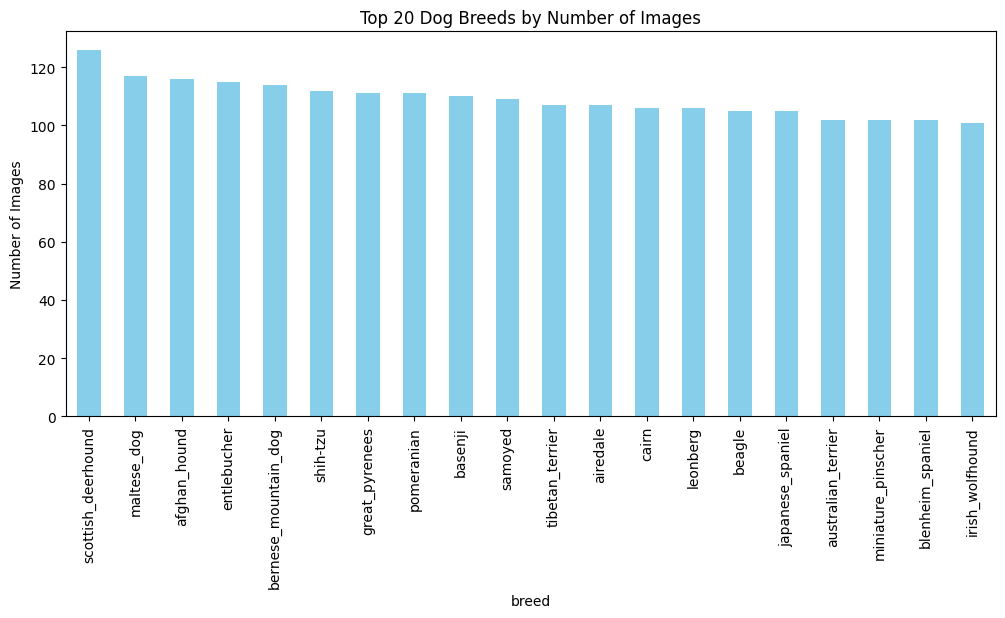

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the labels file (make sure the path is correct)
df = pd.read_csv('./data/dogs/labels.csv')

# Count how many images exist for each breed
breed_counts = df['breed'].value_counts()

# Display the top 20 breeds with the most images
top_20_breeds = breed_counts.head(20)
print("Top 20 breeds by image count:")
print(top_20_breeds)

# Optional: Plot the results
top_20_breeds.plot(kind='bar', figsize=(12, 5), color='skyblue')
plt.title('Top 20 Dog Breeds by Number of Images')
plt.ylabel('Number of Images')
plt.show()

### Wybranie rasy psów, któe moga sprawiać problemy:

| Wyzwanie dla CNN | Pary/Grupy ras | Na co sieć będzie się nabierać? |
|------------------|----------------|----------------------------------|
| Identyczny wzór, inna sierść | bernese_mountain_dog vs entlebucher | Mylenie ras na podstawie koloru zamiast tekstury i kształtu |
| Brak cech barwnych | samoyed vs great_pyrenees vs maltese_dog | Oparcie decyzji o subtelne różnice w proporcjach i sylwetce |
| Zaburzenie geometrii ciała | afghan_hound vs shih-tzu | Błędna interpretacja kształtu przez zmienną pozycję i sierść |

In [3]:
import os
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split

# Define our 10 distinct breeds
# selected_breeds = [
#     'maltese_dog', 'afghan_hound', 'bernese_mountain_dog',
#     'pomeranian', 'basenji', 'airedale', 'leonberg',
#     'beagle', 'japanese_spaniel', 'miniature_pinscher'
# ]

selected_breeds = [
    'bernese_mountain_dog'
    ,'entlebucher'
    ,'leonberg'
    ,'samoyed'
    ,'maltese_dog'
    ,'great_pyrenees'
    ,'airedale'
    ,'cairn'
    ,'afghan_hound'
    ,'shih-tzu'
    ]

# Paths based on your Colab structure
csv_path = './data/dogs/labels.csv'
source_img_dir = './data/dogs/train'
target_base_dir = './dataset'

# Load the labels
df = pd.read_csv(csv_path)

# Filter the dataframe to only include our 10 breeds
df_filtered = df[df['breed'].isin(selected_breeds)]

print(f"Total images for 10 breeds: {len(df_filtered)}")

# Split into train (80%) and validation (20%)
# stratify=df_filtered['breed'] ensures we get an equal percentage of each breed in both sets
train_df, val_df = train_test_split(df_filtered, test_size=0.3, stratify=df_filtered['breed'], random_state=42)
val_df, test_df = train_test_split(df_filtered, test_size=0.4, stratify=df_filtered['breed'], random_state=42)

print(f"Training images: {len(train_df)}")
print(f"Validation images: {len(val_df)}")
print(f"Test images: {len(test_df)}")


# Function to create folders and copy images
def prepare_dataset(dataframe, split_name):
    for index, row in dataframe.iterrows():
        img_id = row['id']
        breed = row['breed']

        # Source file path (Kaggle IDs don't have .jpg in the CSV, so we add it)
        src_path = os.path.join(source_img_dir, f"{img_id}.jpg")

        # Destination directory: ./dataset/train/breed_name/
        dest_dir = os.path.join(target_base_dir, split_name, breed)
        os.makedirs(dest_dir, exist_ok=True)

        # Destination file path
        dest_path = os.path.join(dest_dir, f"{img_id}.jpg")

        # Copy the file
        if os.path.exists(src_path):
            shutil.copy(src_path, dest_path)
        else:
            print(f"Warning: File not found {src_path}")

# Run the preparation
print("Copying training images...")
prepare_dataset(train_df, 'train')

print("Copying validation images...")
prepare_dataset(val_df, 'val')

print("Copying test images...")
prepare_dataset(test_df, 'test')

print(f"Dataset successfully created at {target_base_dir}!")

Total images for 10 breeds: 1113
Training images: 779
Validation images: 667
Test images: 446
Copying training images...
Copying validation images...
Copying test images...
Dataset successfully created at ./dataset!


## Augmentacja danych

W zbiorze treningowym zastosowano augmentację danych realizowaną podczas wczytywania obrazów. Każde zdjęcie było najpierw skalowane do rozmiaru 256 pikseli, a następnie losowo przycinane do rozmiaru 224×224 piksele (`RandomResizedCrop`). Dodatkowo z prawdopodobieństwem 50% wykonywano poziome i pionowe odbicie lustrzane obrazu (`RandomHorizontalFlip`).

W celu zwiększenia odporności modelu na zmiany warunków oświetleniowych zastosowano losowe modyfikacje jasności, kontrastu i nasycenia kolorów (`ColorJitter`) w zakresie ±20% względem wartości oryginalnych. Po wykonaniu augmentacji obrazy były zamieniane na tensory i normalizowane przy użyciu średnich oraz odchyleń standardowych wykorzystywanych dla zbioru ImageNet.

Dla zbioru walidacyjnego nie stosowano losowych transformacji. Obrazy były jedynie skalowane do 256 pikseli, przycinane centralnie do rozmiaru 224×224 piksele, a następnie normalizowane.


In [4]:
from PIL import Image
from torchvision import transforms
import os

augment = transforms.Compose([
    transforms.Resize(300),  # skalowanie
    transforms.RandomCrop(224),  # losowe wycięcie 224x224

    transforms.RandomHorizontalFlip(p=5.0),
    transforms.RandomRotation(30),
    transforms.RandomVerticalFlip(p=5.0),
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.4
    )
])

for class_name in os.listdir("./dataset/train"):
    class_dir = os.path.join("./dataset/train", class_name)
    print(f'Augmentacja danych uczących: {class_name}')

    for filename in os.listdir(class_dir):
        path = os.path.join(class_dir, filename)

        img = Image.open(path).convert("RGB")

        for i in range(4):  # 4 nowe kopie
            aug_img = augment(img)
            aug_img.save(
                os.path.join(
                    class_dir,
                    f"{os.path.splitext(filename)[0]}_aug{i}.jpg"
                )
            )

for class_name in os.listdir("./dataset/val"):
    class_dir = os.path.join("./dataset/val", class_name)
    print(f'Augmentacja danych validacyjnych: {class_name}')

    for filename in os.listdir(class_dir):
        path = os.path.join(class_dir, filename)

        img = Image.open(path).convert("RGB")

        for i in range(3):  # 3 nowe kopie
            aug_img = augment(img)
            aug_img.save(
                os.path.join(
                    class_dir,
                    f"{os.path.splitext(filename)[0]}_aug{i}.jpg"
                )
            )

for class_name in os.listdir("./dataset/test"):
    class_dir = os.path.join("./dataset/test", class_name)
    print(f'Augmentacja danych Testowych: {class_name}')

    for filename in os.listdir(class_dir):
        path = os.path.join(class_dir, filename)

        img = Image.open(path).convert("RGB")

        for i in range(2):  # 2 nowe kopie
            aug_img = augment(img)
            aug_img.save(
                os.path.join(
                    class_dir,
                    f"{os.path.splitext(filename)[0]}_aug{i}.jpg"
                )
            )

Augmentacja danych uczących: great_pyrenees
Augmentacja danych uczących: maltese_dog
Augmentacja danych uczących: leonberg
Augmentacja danych uczących: afghan_hound
Augmentacja danych uczących: cairn
Augmentacja danych uczących: shih-tzu
Augmentacja danych uczących: samoyed
Augmentacja danych uczących: airedale
Augmentacja danych uczących: bernese_mountain_dog
Augmentacja danych uczących: entlebucher
Augmentacja danych validacyjnych: great_pyrenees
Augmentacja danych validacyjnych: maltese_dog
Augmentacja danych validacyjnych: leonberg
Augmentacja danych validacyjnych: afghan_hound
Augmentacja danych validacyjnych: cairn
Augmentacja danych validacyjnych: shih-tzu
Augmentacja danych validacyjnych: samoyed
Augmentacja danych validacyjnych: airedale
Augmentacja danych validacyjnych: bernese_mountain_dog
Augmentacja danych validacyjnych: entlebucher
Augmentacja danych Testowych: great_pyrenees
Augmentacja danych Testowych: maltese_dog
Augmentacja danych Testowych: leonberg
Augmentacja dany

In [ ]:
# import os
# import torch
# from torchvision import datasets, transforms
# from torch.utils.data import DataLoader

# # Setup augmented data pipeline with exposure adjustments
# data_transforms = {
#     'train': transforms.Compose([
#         transforms.Resize(256),
#         transforms.RandomResizedCrop(224),
#         transforms.RandomHorizontalFlip(),
#         transforms.RandomVerticalFlip(), # Added vertical flip
#         transforms.RandomRotation(degrees=30), # Added random rotation
#         transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3), # Increased jitter intensity
#         transforms.ToTensor(),
#         transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
#     ]),
#     'val': transforms.Compose([
#         transforms.Resize(256),
#         transforms.CenterCrop(224),
#         transforms.ToTensor(),
#         transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
#     ]),
# }

# data_dir = './dataset'

# image_datasets = {
#     x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
#     for x in ['train', 'val']
# }

# dataloaders = {
#     x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x == 'train'), num_workers=2)
#     for x in ['train', 'val']
# }

# dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
# class_names = image_datasets['train'].classes
# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

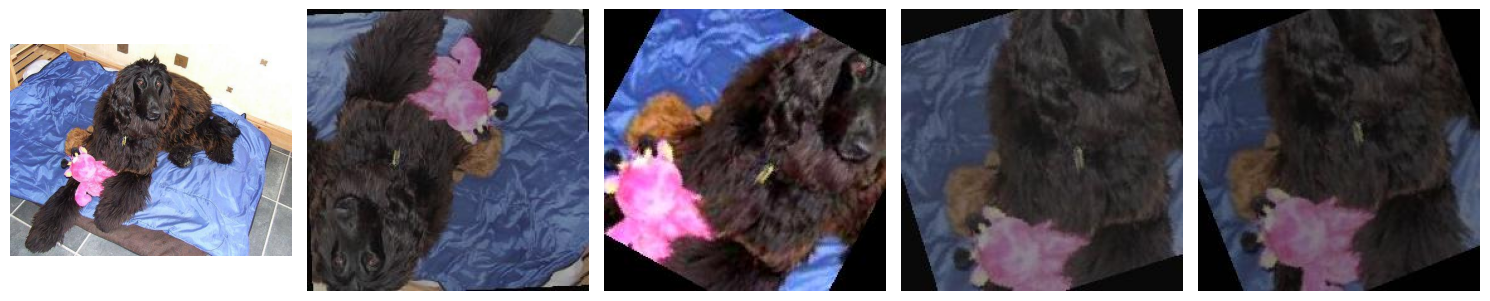

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import glob
import os

# baza nazwy pliku (bez _aug i bez rozszerzenia)
base_name = "0379145880ad3978f9b80f0dc2c03fba"

# folder z danymi
folder = "./dataset/train/afghan_hound"

# znajdź wszystkie wersje tego obrazu
paths = glob.glob(os.path.join(folder, f"{base_name}*.jpg"))

# sortowanie żeby były w kolejności
paths = sorted(paths)

# wizualizacja
plt.figure(figsize=(15, 5))

for i, p in enumerate(paths[:5]):  # max 5 obrazów
    img = Image.open(p).convert("RGB")

    plt.subplot(1, len(paths[:5]), i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Ładowanie datatestu do treningu

In [6]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_dir = './dataset'

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),  # dla pierwotnego zdjęcia
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),

    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),

    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])
}

image_datasets = {
    x: datasets.ImageFolder(
        os.path.join(data_dir, x),
        data_transforms[x]
    )
    for x in ['train', 'val', 'test']
}

dataloaders = {
    x: DataLoader(
        image_datasets[x],
        batch_size=32,
        shuffle=(x == 'train'),
        num_workers=2
    )
    for x in ['train', 'val', 'test']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Train:", dataset_sizes['train'])
print("Val:", dataset_sizes['val'])
print("Test:", dataset_sizes['test'])

Train: 16359
Val: 8671
Test: 3122


# Pętla treningowa

In [7]:
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# 1. Set up device for Colab T4 GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 5. Define the Training Loop with History and Time Logging
def train_model(model, criterion, optimizer, num_epochs=30,exp_name="scratch", checkpoint_path="best_model"):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Dictionary to store history for plotting and analysis
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'epoch_times': [],
        'total_time': 0.0
    }

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        epoch_start = time.time()

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            # Store metrics
            history[f'{phase}_loss'].append(float(epoch_loss))
            history[f'{phase}_acc'].append(float(epoch_acc))

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

                torch.save({
                    'epoch': epoch,
                    'model_state_dict': best_model_wts,
                    'optimizer_state_dict': optimizer.state_dict(),
                    'best_acc': best_acc,
                    'history': history
                }, checkpoint_path)

                print(f"💾 Best model saved (acc={best_acc:.4f}) -> {checkpoint_path}")

        epoch_duration = time.time() - epoch_start
        history['epoch_times'].append(epoch_duration)
        print(f'Epoch Time: {epoch_duration // 60:.0f}m {epoch_duration % 60:.0f}s\n')

    total_time_elapsed = time.time() - since
    history['total_time'] = total_time_elapsed
    print(f'Training complete in {total_time_elapsed // 60:.0f}m {total_time_elapsed % 60:.0f}s')
    print(f'Best Val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    save_experiment_results(history, exp_name)
    return model, history




Using device: cpu


# Eksperymenty

### Funkcje pomocnicze

In [8]:
import os
import json

def save_experiment_results(history, exp_name):
    """Saves history JSON and basic plots to a specific folder."""
    path = f'./results_{exp_name}'
    os.makedirs(path, exist_ok=True)

    with open(os.path.join(path, 'history.json'), 'w') as f:
        json.dump(history, f)

    print(f"Results for {exp_name} saved to {path}")

# Example usage for your latest experiment:
# save_experiment_results(history_unfrozen, 'fine_tuning_unfrozen')

In [9]:
import matplotlib.pyplot as plt
import os
import json

def compare_results_folders(folder_names, metric='val_acc'):
    """
    Compare multiple experiments by providing their folder names.
    folder_names: list of strings like ['results_exp1', 'results_exp21']
    metric: 'train_loss', 'val_loss', 'train_acc', or 'val_acc'
    """
    plt.figure(figsize=(10, 6))

    for folder in folder_names:
        file_path = f'./{folder}/history.json'
        if os.path.exists(file_path):
            with open(file_path, 'r') as f:
                history = json.load(f)

            if metric in history:
                plt.plot(history[metric], label=folder)
        else:
            print(f"Warning: {file_path} not found.")

    plt.title(f'Comparison of {metric}')
    plt.xlabel('Epochs')
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig(f'./comparison_{metric}.png')
    plt.show()


In [10]:
import torch
import torch.nn as nn
from torchvision import models

def load_model(checkpoint_path, num_classes, device):
    # 1. load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # 2. rebuild AlexNet
    model = models.alexnet(weights=None)

    # 3. replace classifier head
    num_ftrs = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_ftrs, num_classes)

    # 4. load weights
    model.load_state_dict(checkpoint['model_state_dict'])

    model = model.to(device)
    model.eval()

    best_acc = checkpoint.get('best_acc', None)

    if isinstance(best_acc, (float, int)):
        print(f"Model loaded. Best acc: {best_acc:.4f}")
    else:
        print("Model loaded. Best acc: unknown")

    return model

In [11]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_confusion_matrix(model, dataloader, class_names, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    print("Classification report:")
    print(classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    ))

    return cm, all_labels, all_preds

def analyze_top_confusions(cm, class_names, top_n=4):
    """Zwraca najczęściej mylone pary klas (poza diagonalą)."""
    cm_copy = cm.copy()
    np.fill_diagonal(cm_copy, 0)
    flat_indices = np.argsort(cm_copy.flatten())[::-1]
    pairs = []
    for idx in flat_indices:
        true_idx = idx // len(class_names)
        pred_idx = idx % len(class_names)
        count = cm_copy[true_idx, pred_idx]
        if count > 0:
            pairs.append((class_names[true_idx], class_names[pred_idx], int(count)))
        if len(pairs) >= top_n:
            break
    return pairs


def plot_confusion_matrix_for_experiment(exp_id, title, dataloader_key='test', save=True):
    """Ładuje model z checkpointu i rysuje macierz pomyłek."""
    import os
    import matplotlib.pyplot as plt
    import seaborn as sns

    checkpoint_path = f'./results_{exp_id}/best_model.pth'
    if not os.path.exists(checkpoint_path):
        print(f'Pominięto {exp_id}: brak wag ({checkpoint_path})')
        return None

    model = load_model(checkpoint_path, num_classes=len(class_names), device=device)
    cm, y_true, y_pred = evaluate_confusion_matrix(
        model, dataloaders[dataloader_key], class_names, device
    )

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names
    )
    plt.title(f'Macierz pomyłek - {title}')
    plt.xlabel('Predykcja')
    plt.ylabel('Rzeczywista klasa')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    if save:
        os.makedirs('./macierze_pomylek', exist_ok=True)
        plt.savefig(
            f'./macierze_pomylek/{exp_id}_confusion_matrix.png',
            dpi=200, bbox_inches='tight'
        )

    plt.show()

    pairs = analyze_top_confusions(cm, class_names)
    if pairs:
        print('\nNajczęściej mylone pary klas:')
        for i, (true_cls, pred_cls, count) in enumerate(pairs, 1):
            print(f'  {i}. {true_cls} → {pred_cls} ({count} przypadków)')

    return cm, y_true, y_pred


In [12]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

def confusion_matrix_from_model(model, dataloader, class_names, device):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)

    print("Classification report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    return cm

## Eksperyment 1 - pełny trening

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Define the absolute path for Experiment 1 weight storage
checkpoint_path_exp1 = './results_exp1/best_model.pth'

if not os.path.exists(checkpoint_path_exp1):
    print("Local cache not found. Initializing Experiment 1 (Training from scratch - 100 epochs)...")
    os.makedirs(os.path.dirname(checkpoint_path_exp1), exist_ok=True)

    # Initialize clean architecture without pre-trained ImageNet weights
    model_scratch = models.alexnet(weights=None)
    num_ftrs = model_scratch.classifier[6].in_features
    model_scratch.classifier[6] = nn.Linear(num_ftrs, 10)
    model_scratch = model_scratch.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=0.0001)

    # Execute full baseline training sequence
    model_scratch, history_scratch = train_model(
        model_scratch, criterion, optimizer_scratch, num_epochs=100, exp_name="exp1", checkpoint_path=checkpoint_path_exp1
    )
else:
    print("Experiment 1 cache hit! Skipping execution. Baseline logs and weights are safe on disk.")

Local cache not found. Initializing Experiment 1 (Training from scratch - 100 epochs)...
Epoch 1/100
----------
Train Loss: 2.2815 Acc: 0.1338
Val Loss: 2.2980 Acc: 0.1248
💾 Best model saved (acc=0.1248) -> /content/results_exp1/best_model.pth
Epoch Time: 0m 26s

Epoch 2/100
----------
Train Loss: 2.1950 Acc: 0.1579
Val Loss: 2.1637 Acc: 0.1773
💾 Best model saved (acc=0.1773) -> /content/results_exp1/best_model.pth
Epoch Time: 0m 21s

Epoch 3/100
----------
Train Loss: 2.1259 Acc: 0.2018
Val Loss: 2.0716 Acc: 0.2256
💾 Best model saved (acc=0.2256) -> /content/results_exp1/best_model.pth
Epoch Time: 0m 27s

Epoch 4/100
----------
Train Loss: 1.9968 Acc: 0.2485
Val Loss: 1.8876 Acc: 0.2811
💾 Best model saved (acc=0.2811) -> /content/results_exp1/best_model.pth
Epoch Time: 0m 22s

Epoch 5/100
----------
Train Loss: 1.8994 Acc: 0.2814
Val Loss: 1.8577 Acc: 0.2837
💾 Best model saved (acc=0.2837) -> /content/results_exp1/best_model.pth
Epoch Time: 0m 17s

Epoch 6/100
----------
Train Loss: 1

### Ewaluacja Modelu

Model loaded. Best acc: unknown
Classification report:
                      precision    recall  f1-score   support

        afghan_hound       0.43      0.60      0.50       141
            airedale       0.48      0.54      0.51       129
bernese_mountain_dog       0.57      0.47      0.51       138
               cairn       0.40      0.32      0.35       126
         entlebucher       0.60      0.67      0.63       138
      great_pyrenees       0.40      0.39      0.39       132
            leonberg       0.59      0.55      0.57       126
         maltese_dog       0.48      0.53      0.51       141
             samoyed       0.54      0.44      0.48       132
            shih-tzu       0.52      0.44      0.48       135

            accuracy                           0.50      1338
           macro avg       0.50      0.50      0.49      1338
        weighted avg       0.50      0.50      0.49      1338



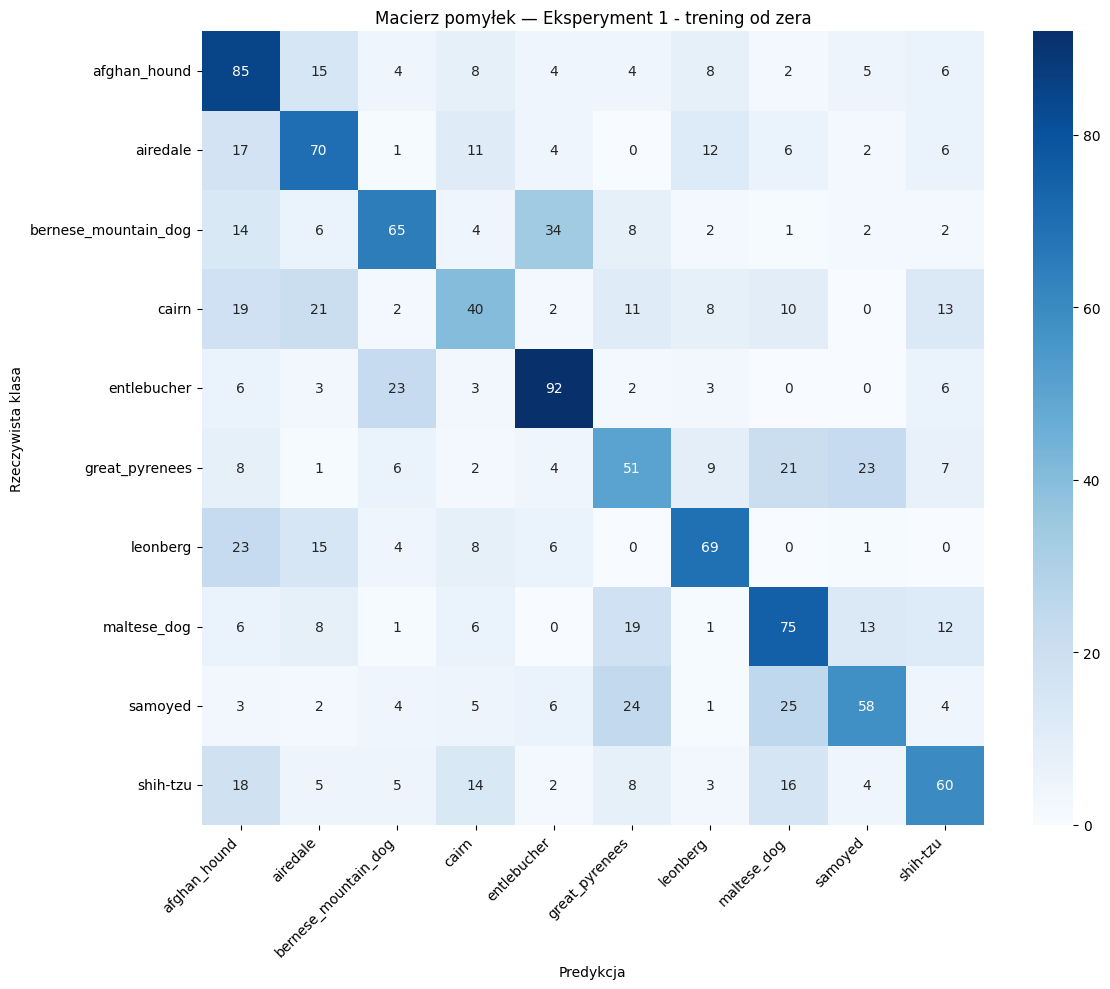


Najczęściej mylone pary klas:
  1. bernese_mountain_dog → entlebucher (34 przypadków)
  2. samoyed → maltese_dog (25 przypadków)
  3. samoyed → great_pyrenees (24 przypadków)
  4. leonberg → afghan_hound (23 przypadków)


(array([[85, 15,  4,  8,  4,  4,  8,  2,  5,  6],
        [17, 70,  1, 11,  4,  0, 12,  6,  2,  6],
        [14,  6, 65,  4, 34,  8,  2,  1,  2,  2],
        [19, 21,  2, 40,  2, 11,  8, 10,  0, 13],
        [ 6,  3, 23,  3, 92,  2,  3,  0,  0,  6],
        [ 8,  1,  6,  2,  4, 51,  9, 21, 23,  7],
        [23, 15,  4,  8,  6,  0, 69,  0,  1,  0],
        [ 6,  8,  1,  6,  0, 19,  1, 75, 13, 12],
        [ 3,  2,  4,  5,  6, 24,  1, 25, 58,  4],
        [18,  5,  5, 14,  2,  8,  3, 16,  4, 60]]),
 [np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  n

In [ ]:
plot_confusion_matrix_for_experiment("exp1", "Eksperyment 1 - trening od zera")


## Eksperyment 2.1 - Wytrenowany model, zamrożony backbone fine tuning tylko klasyfikatora

### Nauka modelu
Nie uruchamiać, jeśli nie chce się uczyć modelu na nowo

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Define the absolute path for Experiment 2.1 weight storage
checkpoint_path_exp21 = './results_exp21/best_model.pth'

if not os.path.exists(checkpoint_path_exp21):
    print("Local cache not found. Initializing Experiment 2.1 (Feature Extractor)...")
    os.makedirs(os.path.dirname(checkpoint_path_exp21), exist_ok=True) # ------------ TU DODNE ZEBY ZAPISAC NAJLEPSZY MODEL ------------

    # Load pre-trained backbone and freeze feature extraction maps
    model_conv = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
    for param in model_conv.features.parameters():
        param.requires_grad = False

    # Parameters of newly constructed modules have requires_grad=True by default
    num_ftrs = model_conv.classifier[6].in_features
    model_conv.classifier[6] = nn.Linear(num_ftrs, 10)
    model_conv = model_conv.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer_conv = optim.Adam(model_conv.classifier[6].parameters(), lr=0.0001)

    # Train only the fully connected head layers
    model_conv, history_conv = train_model(
        model_conv, criterion, optimizer_conv, num_epochs=50, exp_name="exp21", checkpoint_path=checkpoint_path_exp21 # ------------ TU DODNE ZEBY ZAPISAC NAJLEPSZY MODEL ------------
    )

    os.makedirs(os.path.dirname(checkpoint_path_exp21), exist_ok=True)

    torch.save({
        'model_state_dict': model_conv.state_dict(),
        'optimizer_state_dict': optimizer_conv.state_dict(),
        'history': history_conv
    }, checkpoint_path_exp21)
else:
    print("Experiment 2.1 cache hit! Skipping execution. Extractor logs and weights are safe on disk.")

Local cache not found. Initializing Experiment 2.1 (Feature Extractor)...
Epoch 1/50
----------
Train Loss: 1.6349 Acc: 0.4367
Val Loss: 1.1396 Acc: 0.6522
💾 Best model saved (acc=0.6522) -> /content/results_exp21/best_model.pth
Epoch Time: 0m 15s

Epoch 2/50
----------
Train Loss: 1.0254 Acc: 0.6650
Val Loss: 0.8989 Acc: 0.7136
💾 Best model saved (acc=0.7136) -> /content/results_exp21/best_model.pth
Epoch Time: 0m 15s

Epoch 3/50
----------
Train Loss: 0.8574 Acc: 0.7158
Val Loss: 0.7860 Acc: 0.7545
💾 Best model saved (acc=0.7545) -> /content/results_exp21/best_model.pth
Epoch Time: 0m 20s

Epoch 4/50
----------
Train Loss: 0.7653 Acc: 0.7425
Val Loss: 0.7149 Acc: 0.7837
💾 Best model saved (acc=0.7837) -> /content/results_exp21/best_model.pth
Epoch Time: 0m 15s

Epoch 5/50
----------
Train Loss: 0.6922 Acc: 0.7759
Val Loss: 0.6622 Acc: 0.7991
💾 Best model saved (acc=0.7991) -> /content/results_exp21/best_model.pth
Epoch Time: 0m 15s

Epoch 6/50
----------
Train Loss: 0.6460 Acc: 0.792

### Ewaluacja modelu

Model loaded. Best acc: unknown
Classification report:
                      precision    recall  f1-score   support

        afghan_hound       0.78      0.81      0.79       141
            airedale       0.79      0.80      0.80       129
bernese_mountain_dog       0.80      0.77      0.79       138
               cairn       0.78      0.75      0.76       126
         entlebucher       0.80      0.91      0.85       138
      great_pyrenees       0.56      0.62      0.59       132
            leonberg       0.84      0.83      0.84       126
         maltese_dog       0.70      0.72      0.71       141
             samoyed       0.73      0.71      0.72       132
            shih-tzu       0.78      0.64      0.70       135

            accuracy                           0.75      1338
           macro avg       0.76      0.75      0.75      1338
        weighted avg       0.76      0.75      0.75      1338



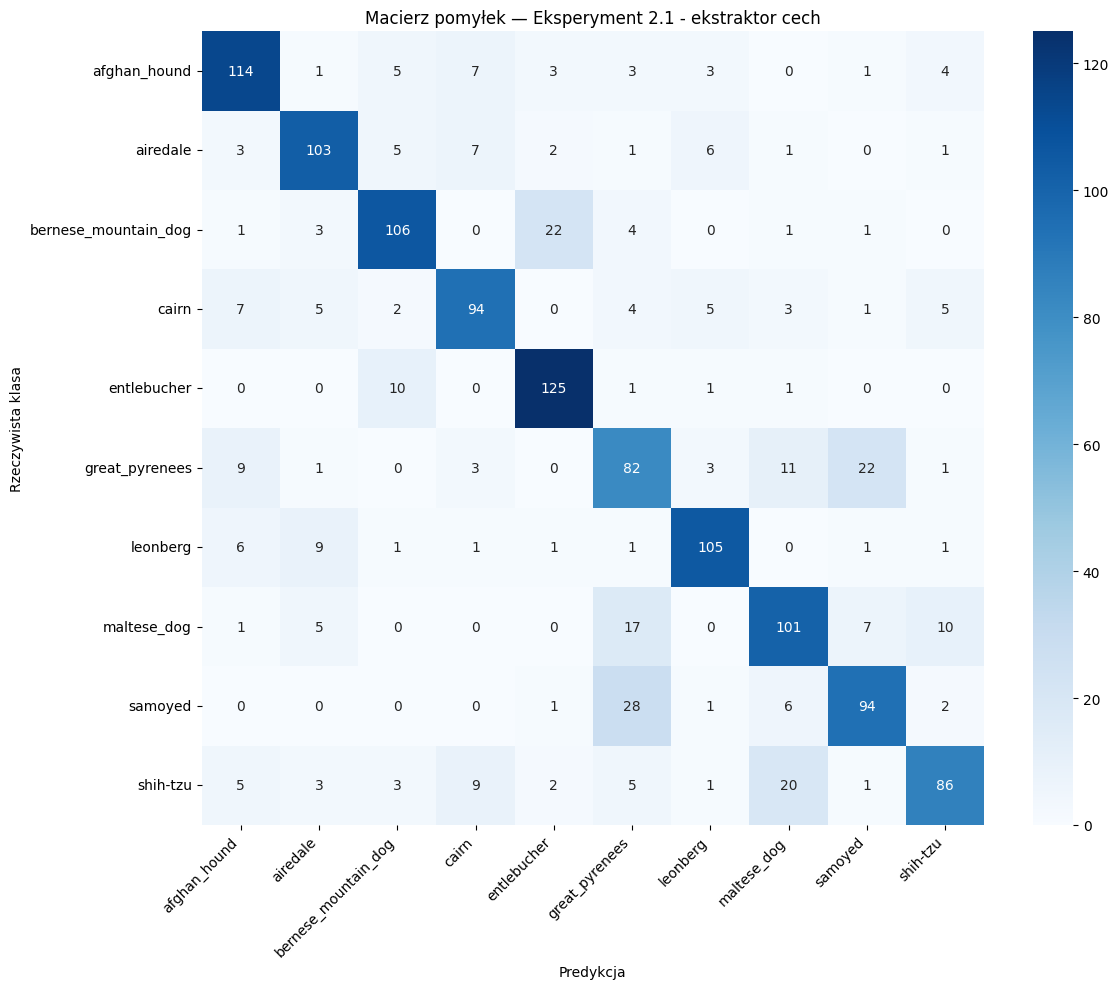


Najczęściej mylone pary klas:
  1. samoyed → great_pyrenees (28 przypadków)
  2. great_pyrenees → samoyed (22 przypadków)
  3. bernese_mountain_dog → entlebucher (22 przypadków)
  4. shih-tzu → maltese_dog (20 przypadków)


(array([[114,   1,   5,   7,   3,   3,   3,   0,   1,   4],
        [  3, 103,   5,   7,   2,   1,   6,   1,   0,   1],
        [  1,   3, 106,   0,  22,   4,   0,   1,   1,   0],
        [  7,   5,   2,  94,   0,   4,   5,   3,   1,   5],
        [  0,   0,  10,   0, 125,   1,   1,   1,   0,   0],
        [  9,   1,   0,   3,   0,  82,   3,  11,  22,   1],
        [  6,   9,   1,   1,   1,   1, 105,   0,   1,   1],
        [  1,   5,   0,   0,   0,  17,   0, 101,   7,  10],
        [  0,   0,   0,   0,   1,  28,   1,   6,  94,   2],
        [  5,   3,   3,   9,   2,   5,   1,  20,   1,  86]]),
 [np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int

In [ ]:
plot_confusion_matrix_for_experiment("exp21", "Eksperyment 2.1 - ekstraktor cech")


1. Najlepiej rozpoznawane rasy psów:
 * entlebucher – bardzo stabilna klasa (wysoka precyzja i recall)
 * leonberg – dobrze odróżniany od innych ras
 * bernese_mountain_dog – wysoki recall (~0.84), dobra separacja
2. Najczęściej mylone klasy
  * shih-tzu - maltese_dog
    * shih-tzu często mylony jako maltese_dog (42 przypadki)
    * silne nakładanie cech małych, jasnych psów
  * great_pyrenees - samoyed
    * duża liczba błędów między tymi rasami
    * model myli duże, białe psy o podobnym futrze
  * bernese_mountain_dog - entlebucher
    * rasy o podobnej budowie i pochodzeniu
    * umiarkowana liczba pomyłek

## Eksperyment 2.2 - Pełny fine tuning, wytrenowany model zonym backbone

###Nauka modelu

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Define the absolute path for Experiment 2.2 weight storage
checkpoint_path_exp22 = './results_exp22/best_model.pth'

if not os.path.exists(checkpoint_path_exp22):
    print("Local cache not found. Initializing Experiment 2.2 (Full Fine-Tuning)...")
    os.makedirs(os.path.dirname(checkpoint_path_exp22), exist_ok=True)

    # Load default ImageNet weights for global low-level adjustments
    model_unfrozen = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
    num_ftrs = model_unfrozen.classifier[6].in_features
    model_unfrozen.classifier[6] = nn.Linear(num_ftrs, 10)
    model_unfrozen = model_unfrozen.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer_unfrozen = optim.Adam(model_unfrozen.parameters(), lr=0.0001)

    # Train all layers with small learning rate
    model_unfrozen, history_unfrozen = train_model(
        model_unfrozen, criterion, optimizer_unfrozen, num_epochs=50, exp_name="exp22", checkpoint_path=checkpoint_path_exp22
    )
else:
    print("Experiment 2.2 cache hit! Loading fine-tuned weights for downstream analysis...")

    # Reconstruct empty structural shell of target architecture
    model_unfrozen = models.alexnet(weights=None)
    num_ftrs = model_unfrozen.classifier[6].in_features
    model_unfrozen.classifier[6] = nn.Linear(num_ftrs, 10)

    # Load frozen parameters into system memory
    model_unfrozen.load_state_dict(torch.load(checkpoint_path_exp22))
    model_unfrozen = model_unfrozen.to(device)
    model_unfrozen.eval()

###Ewaluacja modelu

In [ ]:
plot_confusion_matrix_for_experiment("exp22", "Eksperyment 2.2 - pełny fine-tuning")


##Porównanie wyników między eksperymentem 2.1 i 2.2

In [ ]:
# Compare accuracy between Experiment 1 and Experiment 2.2 using folder names
#train_loss, train_acc, val_loss, val_acc
compare_results_folders(['results_exp21', 'results_exp22'], metric='train_loss')

## Eksperyment 3.1 - odmrożenie Conv5


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Define the absolute path for Experiment 3.1 weight storage
checkpoint_path_exp31 = './results_exp31/best_model.pth'

if not os.path.exists(checkpoint_path_exp31):
    print("Local cache not found. Initializing Experiment 3.1 (Unfrozen Conv5 only)...")
    os.makedirs(os.path.dirname(checkpoint_path_exp31), exist_ok=True)

    # Eksperyment 3.1: Odmrożenie tylko ostatniej warstwy splotowej (Conv5)
    # Ładowanie wag ImageNet
    model_31 = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)

    # ZAMRAŻANIE CAŁEGO BACKBONE'U
    for param in model_31.features.parameters():
        param.requires_grad = False

    # ODMRAŻANIE TYLKO OSTATNIEJ WARSTWY (Conv5, indeks 10)
    for param in model_31.features[10].parameters():
        param.requires_grad = True

    # Nowy klasyfikator (domyślnie jest odmrożony)
    num_ftrs = model_31.classifier[6].in_features
    model_31.classifier[6] = nn.Linear(num_ftrs, 10)
    model_31 = model_31.to(device)

    # Optymalizator - przekazujemy tylko te parametry, które wymagają gradientu
    criterion = nn.CrossEntropyLoss()
    optimizer_31 = optim.Adam(filter(lambda p: p.requires_grad, model_31.parameters()), lr=0.0005)

    # Execute training sequence
    model_31, history_31 = train_model(
        model_31, criterion, optimizer_31, num_epochs=30, exp_name="exp31", checkpoint_path=checkpoint_path_exp31
    )
else:
    print("Experiment 3.1 cache hit! Skipping execution. Logs and weights are safe on disk.")


Local cache not found. Initializing Experiment 3.1 (Unfrozen Conv5 only)...
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:03<00:00, 78.3MB/s]


Epoch 1/30
----------
Train Loss: 1.1144 Acc: 0.6116
Val Loss: 0.6225 Acc: 0.7849
💾 Best model saved (acc=0.7849) -> /content/results_exp31/best_model.pth
Epoch Time: 1m 8s

Epoch 2/30
----------
Train Loss: 0.4651 Acc: 0.8401
Val Loss: 0.6041 Acc: 0.7965
💾 Best model saved (acc=0.7965) -> /content/results_exp31/best_model.pth
Epoch Time: 0m 32s

Epoch 3/30
----------
Train Loss: 0.2838 Acc: 0.9125
Val Loss: 0.4630 Acc: 0.8433
💾 Best model saved (acc=0.8433) -> /content/results_exp31/best_model.pth
Epoch Time: 0m 34s

Epoch 4/30
----------
Train Loss: 0.1881 Acc: 0.9402
Val Loss: 0.5189 Acc: 0.8490
💾 Best model saved (acc=0.8490) -> /content/results_exp31/best_model.pth
Epoch Time: 0m 26s

Epoch 5/30
----------
Train Loss: 0.1520 Acc: 0.9543
Val Loss: 0.4656 Acc: 0.8692
💾 Best model saved (acc=0.8692) -> /content/results_exp31/best_model.pth
Epoch Time: 1m 8s

Epoch 6/30
----------
Train Loss: 0.1305 Acc: 0.9630
Val Loss: 0.4247 Acc: 0.8804
💾 Best model saved (acc=0.8804) -> /content/r

### Ewaluacja modelu - Eksperyment 3.1


Model loaded. Best acc: unknown
Classification report:
                      precision    recall  f1-score   support

        afghan_hound       0.72      0.84      0.77       141
            airedale       0.89      0.79      0.84       129
bernese_mountain_dog       0.86      0.75      0.80       138
               cairn       0.75      0.77      0.76       126
         entlebucher       0.84      0.83      0.84       138
      great_pyrenees       0.68      0.52      0.59       132
            leonberg       0.72      0.88      0.79       126
         maltese_dog       0.69      0.72      0.71       141
             samoyed       0.67      0.80      0.73       132
            shih-tzu       0.73      0.61      0.67       135

            accuracy                           0.75      1338
           macro avg       0.75      0.75      0.75      1338
        weighted avg       0.75      0.75      0.75      1338



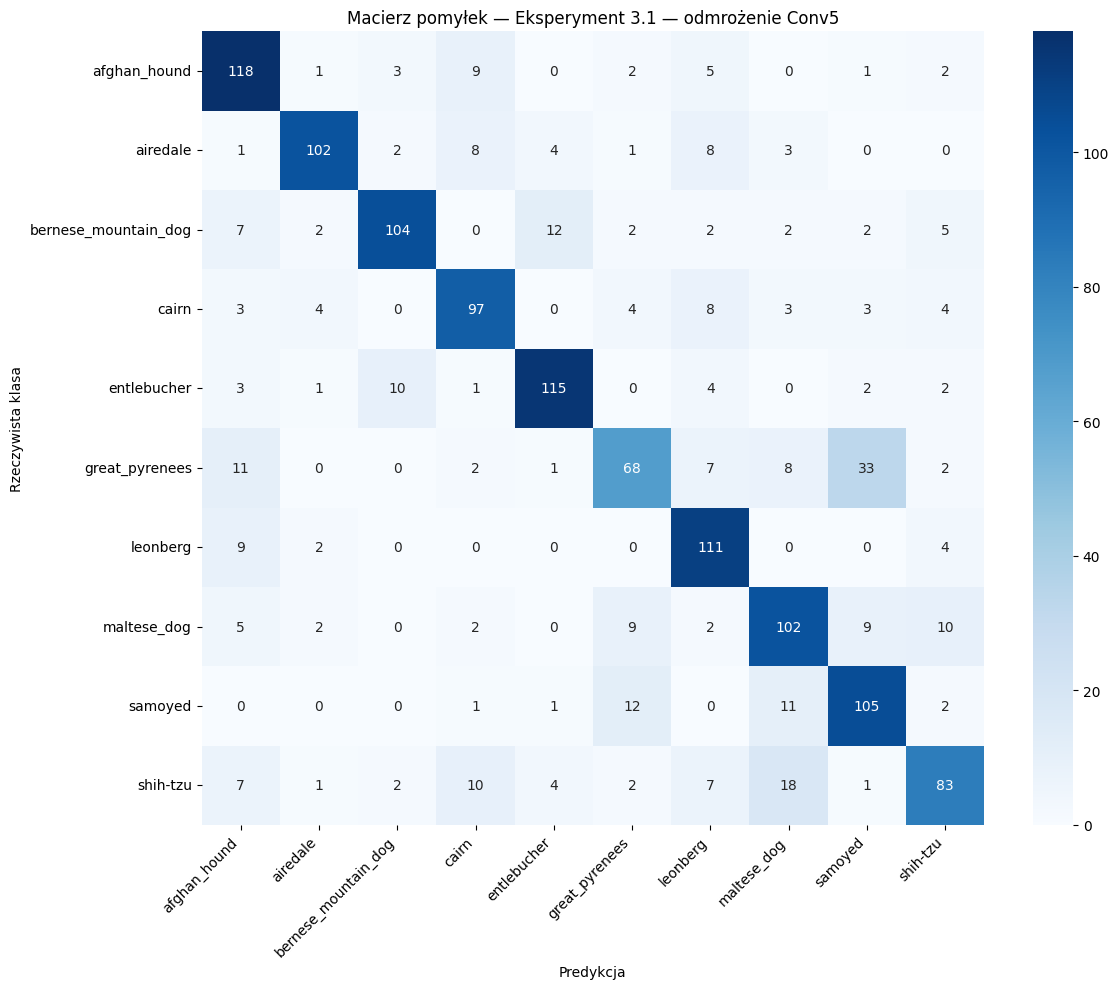


Najczęściej mylone pary klas:
  1. great_pyrenees → samoyed (33 przypadków)
  2. shih-tzu → maltese_dog (18 przypadków)
  3. bernese_mountain_dog → entlebucher (12 przypadków)
  4. samoyed → great_pyrenees (12 przypadków)


(array([[118,   1,   3,   9,   0,   2,   5,   0,   1,   2],
        [  1, 102,   2,   8,   4,   1,   8,   3,   0,   0],
        [  7,   2, 104,   0,  12,   2,   2,   2,   2,   5],
        [  3,   4,   0,  97,   0,   4,   8,   3,   3,   4],
        [  3,   1,  10,   1, 115,   0,   4,   0,   2,   2],
        [ 11,   0,   0,   2,   1,  68,   7,   8,  33,   2],
        [  9,   2,   0,   0,   0,   0, 111,   0,   0,   4],
        [  5,   2,   0,   2,   0,   9,   2, 102,   9,  10],
        [  0,   0,   0,   1,   1,  12,   0,  11, 105,   2],
        [  7,   1,   2,  10,   4,   2,   7,  18,   1,  83]]),
 [np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int

In [ ]:
# Adding an underscore assignment to capture the return values and prevent them from printing automatically
_ = plot_confusion_matrix_for_experiment("exp31", "Eksperyment 3.1 - odmrożenie Conv5")

## Eksperyment 3.2 - odmrożenie Conv4 i Conv5


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Define the absolute path for Experiment 3.2 weight storage
checkpoint_path_exp32 = './results_exp32/best_model.pth'

if not os.path.exists(checkpoint_path_exp32):
    print("Local cache not found. Initializing Experiment 3.2 (Unfrozen Conv4 and Conv5)...")
    os.makedirs(os.path.dirname(checkpoint_path_exp32), exist_ok=True)

    # Eksperyment 3.2: Odmrożenie dwóch ostatnich warstw (Conv4 i Conv5)
    model_32 = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)

    # Zamrożenie całości
    for param in model_32.features.parameters():
        param.requires_grad = False

    # Odmrożenie Conv4 (indeks 8) oraz Conv5 (indeks 10)
    for param in model_32.features[8].parameters():
        param.requires_grad = True
    for param in model_32.features[10].parameters():
        param.requires_grad = True

    model_32.classifier[6] = nn.Linear(model_32.classifier[6].in_features, 10)
    model_32 = model_32.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer_32 = optim.Adam(filter(lambda p: p.requires_grad, model_32.parameters()), lr=0.0005)

    # Execute training sequence
    model_32, history_32 = train_model(
        model_32, criterion, optimizer_32, num_epochs=30, exp_name="exp32", checkpoint_path=checkpoint_path_exp32
    )
else:
    print("Experiment 3.2 cache hit! Skipping execution. Logs and weights are safe on disk.")


Local cache not found. Initializing Experiment 3.2 (Unfrozen Conv4 and Conv5)...
Epoch 1/30
----------
Train Loss: 1.1752 Acc: 0.5841
Val Loss: 0.6757 Acc: 0.7627
💾 Best model saved (acc=0.7627) -> /content/results_exp32/best_model.pth
Epoch Time: 0m 27s

Epoch 2/30
----------
Train Loss: 0.6063 Acc: 0.7979
Val Loss: 0.5341 Acc: 0.8160
💾 Best model saved (acc=0.8160) -> /content/results_exp32/best_model.pth
Epoch Time: 0m 24s

Epoch 3/30
----------
Train Loss: 0.3712 Acc: 0.8791
Val Loss: 0.4875 Acc: 0.8388
💾 Best model saved (acc=0.8388) -> /content/results_exp32/best_model.pth
Epoch Time: 0m 26s

Epoch 4/30
----------
Train Loss: 0.2734 Acc: 0.9145
Val Loss: 0.5091 Acc: 0.8579
💾 Best model saved (acc=0.8579) -> /content/results_exp32/best_model.pth
Epoch Time: 0m 23s

Epoch 5/30
----------
Train Loss: 0.2214 Acc: 0.9322
Val Loss: 0.5977 Acc: 0.8370
Epoch Time: 0m 15s

Epoch 6/30
----------
Train Loss: 0.2043 Acc: 0.9384
Val Loss: 0.4647 Acc: 0.8651
💾 Best model saved (acc=0.8651) -> 

### Ewaluacja modelu - Eksperyment 3.2


Model loaded. Best acc: unknown
Classification report:
                      precision    recall  f1-score   support

        afghan_hound       0.84      0.76      0.80       141
            airedale       0.87      0.82      0.84       129
bernese_mountain_dog       0.73      0.84      0.78       138
               cairn       0.73      0.76      0.74       126
         entlebucher       0.82      0.77      0.79       138
      great_pyrenees       0.63      0.60      0.61       132
            leonberg       0.89      0.82      0.85       126
         maltese_dog       0.64      0.73      0.68       141
             samoyed       0.78      0.74      0.76       132
            shih-tzu       0.69      0.72      0.71       135

            accuracy                           0.76      1338
           macro avg       0.76      0.76      0.76      1338
        weighted avg       0.76      0.76      0.76      1338



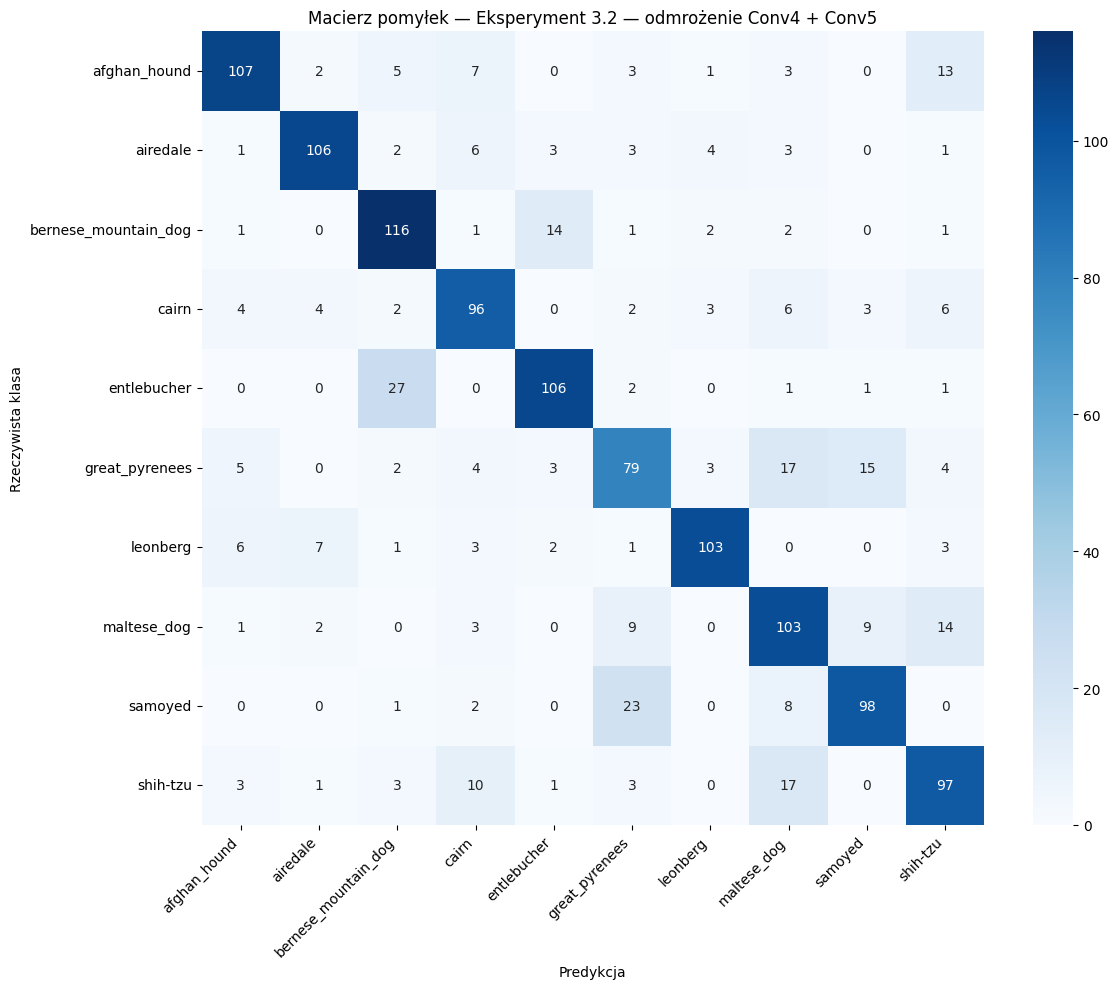


Najczęściej mylone pary klas:
  1. entlebucher → bernese_mountain_dog (27 przypadków)
  2. samoyed → great_pyrenees (23 przypadków)
  3. great_pyrenees → maltese_dog (17 przypadków)
  4. shih-tzu → maltese_dog (17 przypadków)


(array([[107,   2,   5,   7,   0,   3,   1,   3,   0,  13],
        [  1, 106,   2,   6,   3,   3,   4,   3,   0,   1],
        [  1,   0, 116,   1,  14,   1,   2,   2,   0,   1],
        [  4,   4,   2,  96,   0,   2,   3,   6,   3,   6],
        [  0,   0,  27,   0, 106,   2,   0,   1,   1,   1],
        [  5,   0,   2,   4,   3,  79,   3,  17,  15,   4],
        [  6,   7,   1,   3,   2,   1, 103,   0,   0,   3],
        [  1,   2,   0,   3,   0,   9,   0, 103,   9,  14],
        [  0,   0,   1,   2,   0,  23,   0,   8,  98,   0],
        [  3,   1,   3,  10,   1,   3,   0,  17,   0,  97]]),
 [np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int

In [ ]:
plot_confusion_matrix_for_experiment("exp32", "Eksperyment 3.2 - odmrożenie Conv4 + Conv5")


## Eksperyment 4.1 - różnicowe learning rate


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Define the absolute path for Experiment 4.1 weight storage
checkpoint_path_exp41 = './results_exp41/best_model.pth'

if not os.path.exists(checkpoint_path_exp41):
    print("Local cache not found. Initializing Experiment 4.1 (Differential Learning Rate)...")
    os.makedirs(os.path.dirname(checkpoint_path_exp41), exist_ok=True)

    # Eksperyment 4.1: Różnicowe LR (Differential Learning Rate)
    model_41 = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
    model_41.classifier[6] = nn.Linear(model_41.classifier[6].in_features, 10)
    model_41 = model_41.to(device)

    # Różnicowe learning rates:
    # 1e-5 dla pretrenowanych cech, 1e-3 dla nowego klasyfikatora
    criterion = nn.CrossEntropyLoss()
    optimizer_41 = optim.Adam([
        {'params': model_41.features.parameters(), 'lr': 1e-5},
        {'params': model_41.classifier.parameters(), 'lr': 1e-3}
    ])

    # Execute training sequence
    model_41, history_41 = train_model(
        model_41, criterion, optimizer_41, num_epochs=30, exp_name="exp41", checkpoint_path=checkpoint_path_exp41
    )
else:
    print("Experiment 4.1 cache hit! Skipping execution. Logs and weights are safe on disk.")


Local cache not found. Initializing Experiment 4.1 (Differential Learning Rate)...
Epoch 1/30
----------
Train Loss: 1.3964 Acc: 0.5322
Val Loss: 0.8853 Acc: 0.6855
💾 Best model saved (acc=0.6855) -> /content/results_exp41/best_model.pth
Epoch Time: 1m 4s

Epoch 2/30
----------
Train Loss: 0.7645 Acc: 0.7358
Val Loss: 0.5684 Acc: 0.8025
💾 Best model saved (acc=0.8025) -> /content/results_exp41/best_model.pth
Epoch Time: 0m 33s

Epoch 3/30
----------
Train Loss: 0.4924 Acc: 0.8383
Val Loss: 0.5349 Acc: 0.8047
💾 Best model saved (acc=0.8047) -> /content/results_exp41/best_model.pth
Epoch Time: 0m 55s

Epoch 4/30
----------
Train Loss: 0.3468 Acc: 0.8950
Val Loss: 0.5335 Acc: 0.8463
💾 Best model saved (acc=0.8463) -> /content/results_exp41/best_model.pth
Epoch Time: 0m 29s

Epoch 5/30
----------
Train Loss: 0.2648 Acc: 0.9189
Val Loss: 0.5210 Acc: 0.8388
Epoch Time: 0m 16s

Epoch 6/30
----------
Train Loss: 0.2478 Acc: 0.9312
Val Loss: 0.5239 Acc: 0.8407
Epoch Time: 0m 23s

Epoch 7/30
---

### Ewaluacja modelu - Eksperyment 4.1


Model loaded. Best acc: unknown
Classification report:
                      precision    recall  f1-score   support

        afghan_hound       0.83      0.72      0.77       141
            airedale       0.73      0.84      0.78       129
bernese_mountain_dog       0.81      0.70      0.75       138
               cairn       0.77      0.60      0.68       126
         entlebucher       0.75      0.89      0.81       138
      great_pyrenees       0.60      0.61      0.60       132
            leonberg       0.87      0.79      0.82       126
         maltese_dog       0.61      0.74      0.67       141
             samoyed       0.68      0.67      0.68       132
            shih-tzu       0.68      0.67      0.68       135

            accuracy                           0.72      1338
           macro avg       0.73      0.72      0.72      1338
        weighted avg       0.73      0.72      0.72      1338



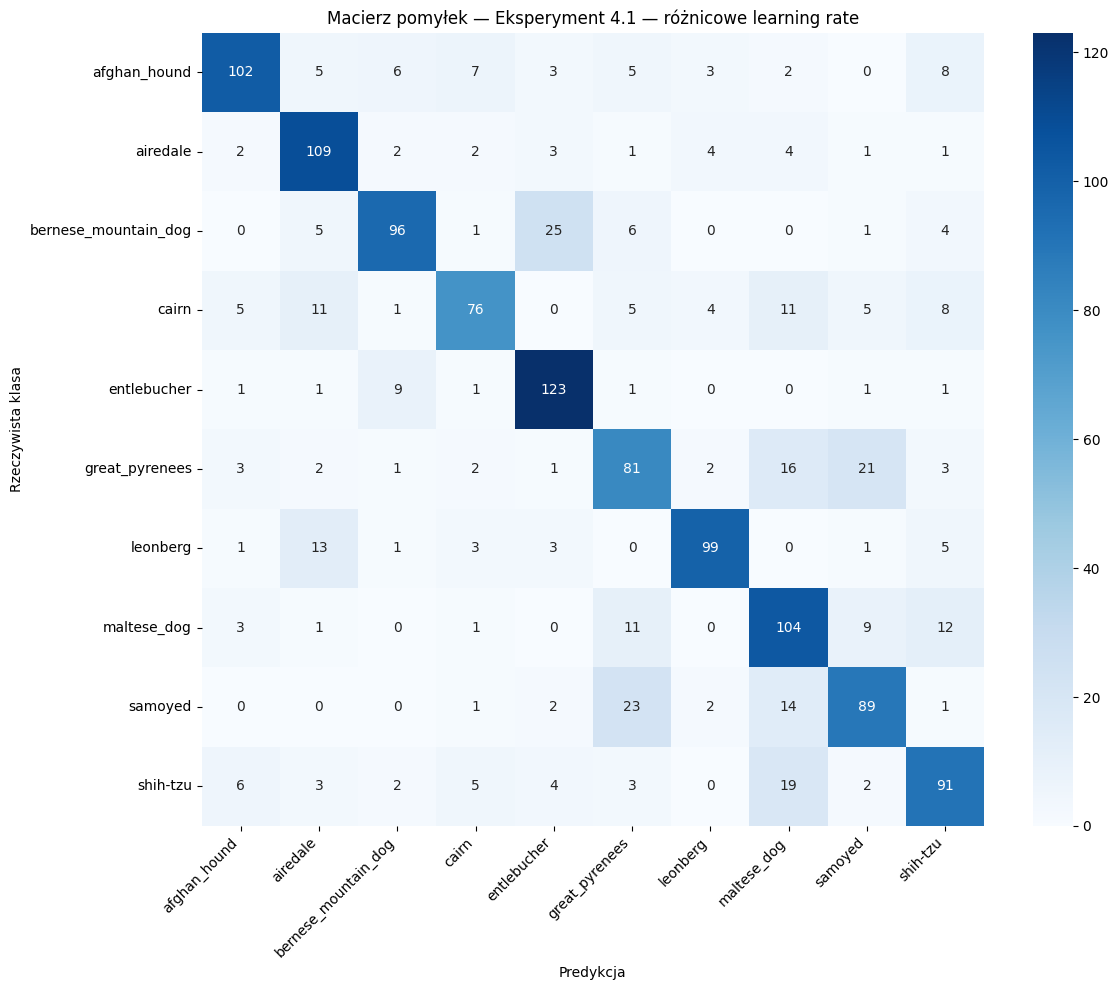


Najczęściej mylone pary klas:
  1. bernese_mountain_dog → entlebucher (25 przypadków)
  2. samoyed → great_pyrenees (23 przypadków)
  3. great_pyrenees → samoyed (21 przypadków)
  4. shih-tzu → maltese_dog (19 przypadków)


(array([[102,   5,   6,   7,   3,   5,   3,   2,   0,   8],
        [  2, 109,   2,   2,   3,   1,   4,   4,   1,   1],
        [  0,   5,  96,   1,  25,   6,   0,   0,   1,   4],
        [  5,  11,   1,  76,   0,   5,   4,  11,   5,   8],
        [  1,   1,   9,   1, 123,   1,   0,   0,   1,   1],
        [  3,   2,   1,   2,   1,  81,   2,  16,  21,   3],
        [  1,  13,   1,   3,   3,   0,  99,   0,   1,   5],
        [  3,   1,   0,   1,   0,  11,   0, 104,   9,  12],
        [  0,   0,   0,   1,   2,  23,   2,  14,  89,   1],
        [  6,   3,   2,   5,   4,   3,   0,  19,   2,  91]]),
 [np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int

In [ ]:
plot_confusion_matrix_for_experiment("exp41", "Eksperyment 4.1 - różnicowe learning rate")


## Eksperyment 5.1 - optymalizator SGD


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Define the absolute path for Experiment 5.1 weight storage
checkpoint_path_exp51 = './results_exp51/best_model.pth'

if not os.path.exists(checkpoint_path_exp51):
    print("Local cache not found. Initializing Experiment 5.1 (SGD Optimizer)...")
    os.makedirs(os.path.dirname(checkpoint_path_exp51), exist_ok=True)

    # Eksperyment 5.1: Zmiana optymalizatora na klasyczny SGD z momentum
    model_51 = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
    model_51.classifier[6] = nn.Linear(model_51.classifier[6].in_features, 10)
    model_51 = model_51.to(device)

    # Używamy SGD zamiast Adam. Momentum = 0.9.
    criterion = nn.CrossEntropyLoss()
    optimizer_51 = optim.SGD(model_51.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

    # Execute training sequence
    model_51, history_51 = train_model(
        model_51, criterion, optimizer_51, num_epochs=30, exp_name="exp51", checkpoint_path=checkpoint_path_exp51
    )
else:
    print("Experiment 5.1 cache hit! Skipping execution. Logs and weights are safe on disk.")


Local cache not found. Initializing Experiment 5.1 (SGD Optimizer)...
Epoch 1/30
----------
Train Loss: 1.1313 Acc: 0.5905
Val Loss: 0.6857 Acc: 0.7590
💾 Best model saved (acc=0.7590) -> /content/results_exp51/best_model.pth
Epoch Time: 0m 22s

Epoch 2/30
----------
Train Loss: 0.6082 Acc: 0.7813
Val Loss: 0.4949 Acc: 0.8268
💾 Best model saved (acc=0.8268) -> /content/results_exp51/best_model.pth
Epoch Time: 0m 53s

Epoch 3/30
----------
Train Loss: 0.3943 Acc: 0.8585
Val Loss: 0.3744 Acc: 0.8718
💾 Best model saved (acc=0.8718) -> /content/results_exp51/best_model.pth
Epoch Time: 0m 20s

Epoch 4/30
----------
Train Loss: 0.2709 Acc: 0.9068
Val Loss: 0.3123 Acc: 0.8936
💾 Best model saved (acc=0.8936) -> /content/results_exp51/best_model.pth
Epoch Time: 0m 26s

Epoch 5/30
----------
Train Loss: 0.1706 Acc: 0.9363
Val Loss: 0.2614 Acc: 0.9134
💾 Best model saved (acc=0.9134) -> /content/results_exp51/best_model.pth
Epoch Time: 1m 2s

Epoch 6/30
----------
Train Loss: 0.1624 Acc: 0.9425
Val

### Ewaluacja modelu - Eksperyment 5.1


Model loaded. Best acc: unknown
Classification report:
                      precision    recall  f1-score   support

        afghan_hound       0.80      0.87      0.83       141
            airedale       0.85      0.88      0.86       129
bernese_mountain_dog       0.85      0.89      0.87       138
               cairn       0.76      0.72      0.74       126
         entlebucher       0.89      0.88      0.88       138
      great_pyrenees       0.72      0.70      0.71       132
            leonberg       0.87      0.87      0.87       126
         maltese_dog       0.75      0.74      0.74       141
             samoyed       0.72      0.86      0.78       132
            shih-tzu       0.88      0.67      0.76       135

            accuracy                           0.81      1338
           macro avg       0.81      0.81      0.81      1338
        weighted avg       0.81      0.81      0.81      1338



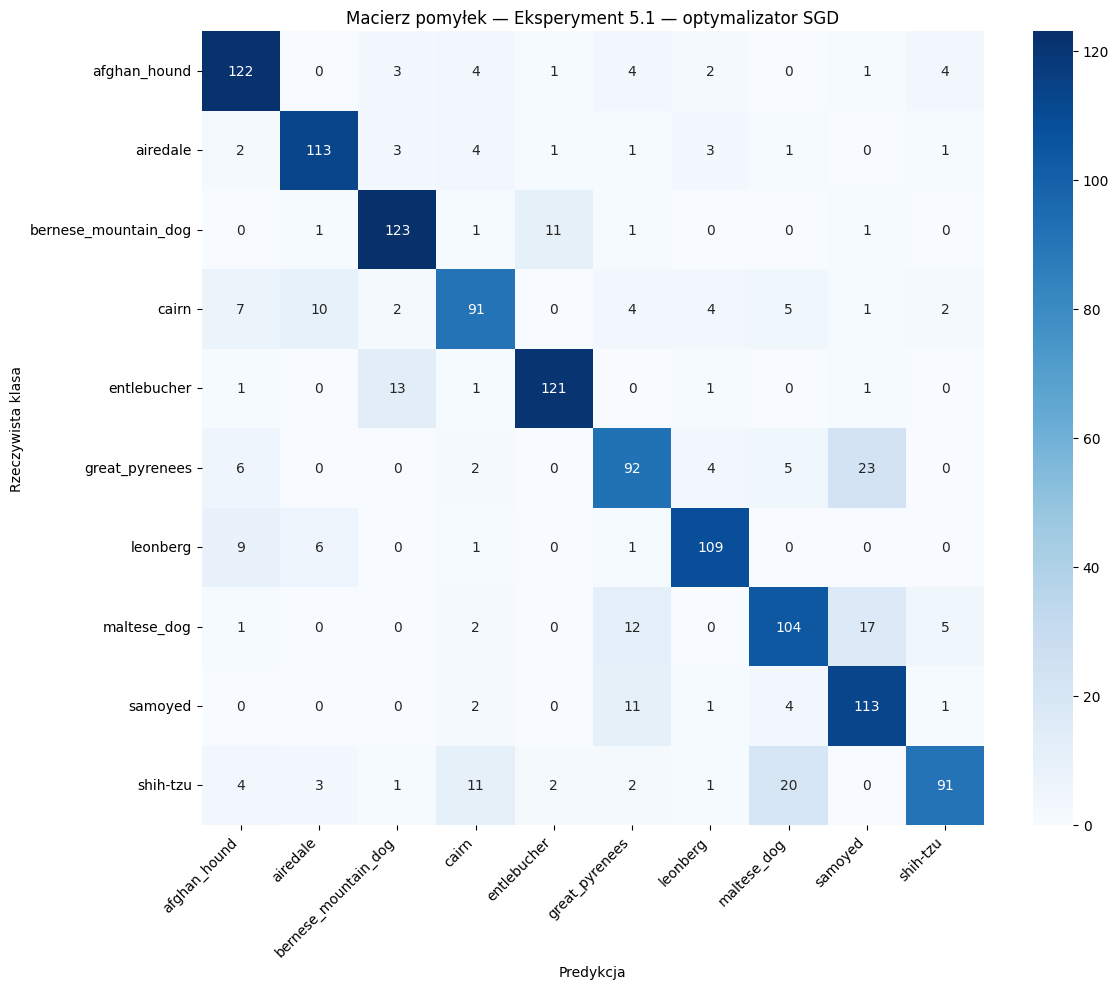


Najczęściej mylone pary klas:
  1. great_pyrenees → samoyed (23 przypadków)
  2. shih-tzu → maltese_dog (20 przypadków)
  3. maltese_dog → samoyed (17 przypadków)
  4. entlebucher → bernese_mountain_dog (13 przypadków)


(array([[122,   0,   3,   4,   1,   4,   2,   0,   1,   4],
        [  2, 113,   3,   4,   1,   1,   3,   1,   0,   1],
        [  0,   1, 123,   1,  11,   1,   0,   0,   1,   0],
        [  7,  10,   2,  91,   0,   4,   4,   5,   1,   2],
        [  1,   0,  13,   1, 121,   0,   1,   0,   1,   0],
        [  6,   0,   0,   2,   0,  92,   4,   5,  23,   0],
        [  9,   6,   0,   1,   0,   1, 109,   0,   0,   0],
        [  1,   0,   0,   2,   0,  12,   0, 104,  17,   5],
        [  0,   0,   0,   2,   0,  11,   1,   4, 113,   1],
        [  4,   3,   1,  11,   2,   2,   1,  20,   0,  91]]),
 [np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int

In [ ]:
plot_confusion_matrix_for_experiment("exp51", "Eksperyment 5.1 - optymalizator SGD")


### Funkcja wizualizacyjna


In [ ]:
import matplotlib.pyplot as plt
import os

def plot_experiment_results(history, exp_name):
    """
    history: słownik zawierający listy wyników: 'train_loss', 'val_loss', 'train_acc', 'val_acc'
    exp_name: nazwa eksperymentu, np. 'exp31'
    """
    epochs = range(len(history['train_loss']))

    # Konwersja tensorów na zwykłe liczby (jeśli accuracy jest zapisane jako tensor)
    train_acc = [acc.item() if torch.is_tensor(acc) else acc for acc in history['train_acc']]
    val_acc = [acc.item() if torch.is_tensor(acc) else acc for acc in history['val_acc']]

    # Tworzenie figury z dwoma wykresami pionowo
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

    # Wykres 1: Funkcja Straty (Loss)
    ax1.plot(epochs, history['train_loss'], label='Train Loss', color='darkblue')
    ax1.plot(epochs, history['val_loss'], label='Validation Loss', color='orange', alpha=0.7)
    ax1.set_title(f'Eksperyment {exp_name} - Funkcja Straty (Loss)')
    ax1.set_xlabel('Epoka')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Wykres 2: Dokładność (Accuracy)
    ax2.plot(epochs, train_acc, label='Train Accuracy', color='darkgreen')
    ax2.plot(epochs, val_acc, label='Validation Accuracy', color='crimson')
    ax2.set_title(f'Eksperyment {exp_name} - Dokładność (Accuracy)')
    ax2.set_xlabel('Epoka')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()

    # Zapis do pliku
    os.makedirs('wykresy', exist_ok=True)
    filename = f'wykresy/{exp_name}_results.png'
    plt.savefig(filename, dpi=300)
    print(f"Zapisano wykres do pliku: {filename}")
    plt.show()

### Trening i wykresy - eksperymenty 3.1, 3.2, 4.1, 5.1


Zapisano wykres do pliku: wykresy/exp31_results.png


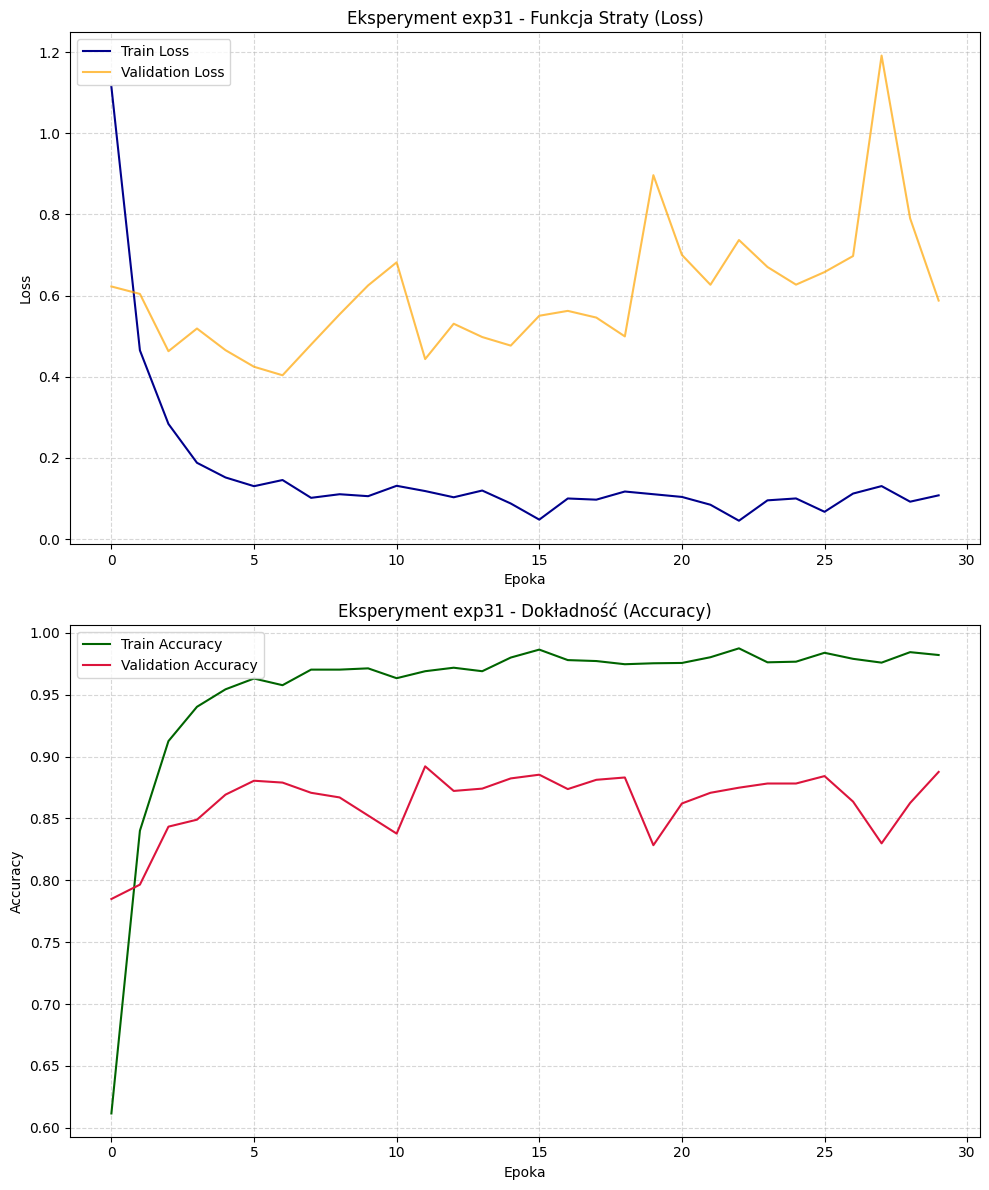

Zapisano wykres do pliku: wykresy/exp32_results.png


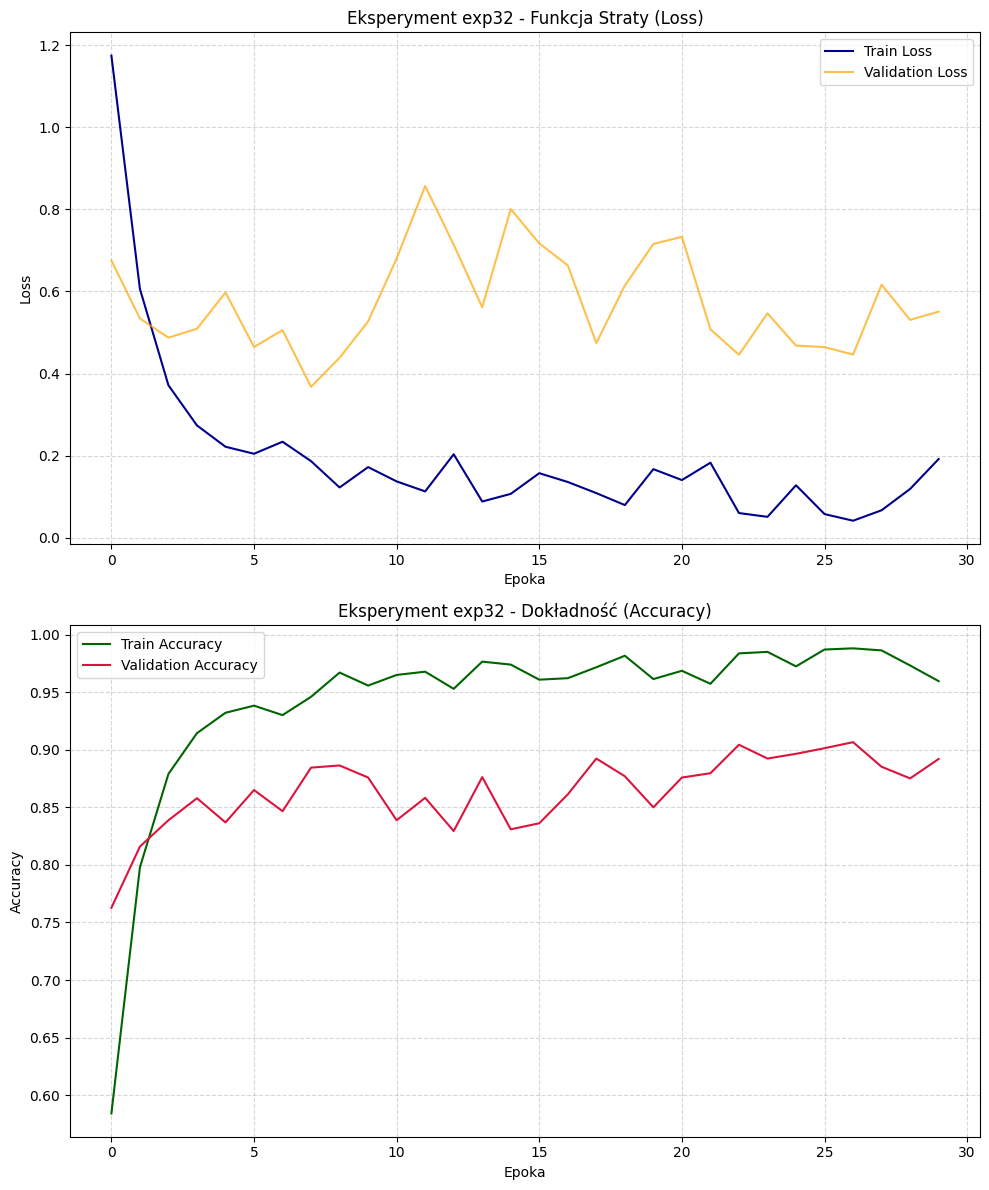

Zapisano wykres do pliku: wykresy/exp41_results.png


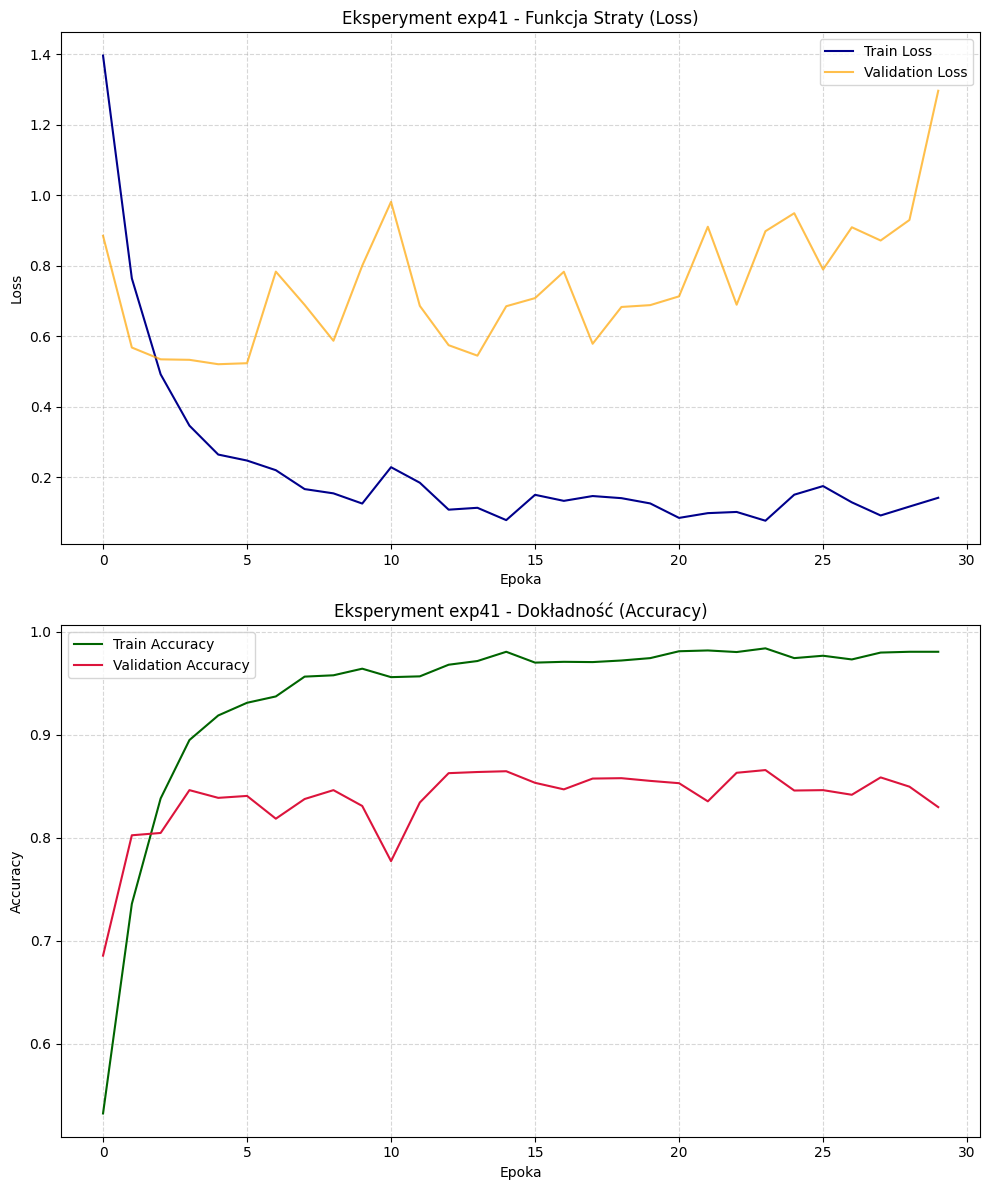

Zapisano wykres do pliku: wykresy/exp51_results.png


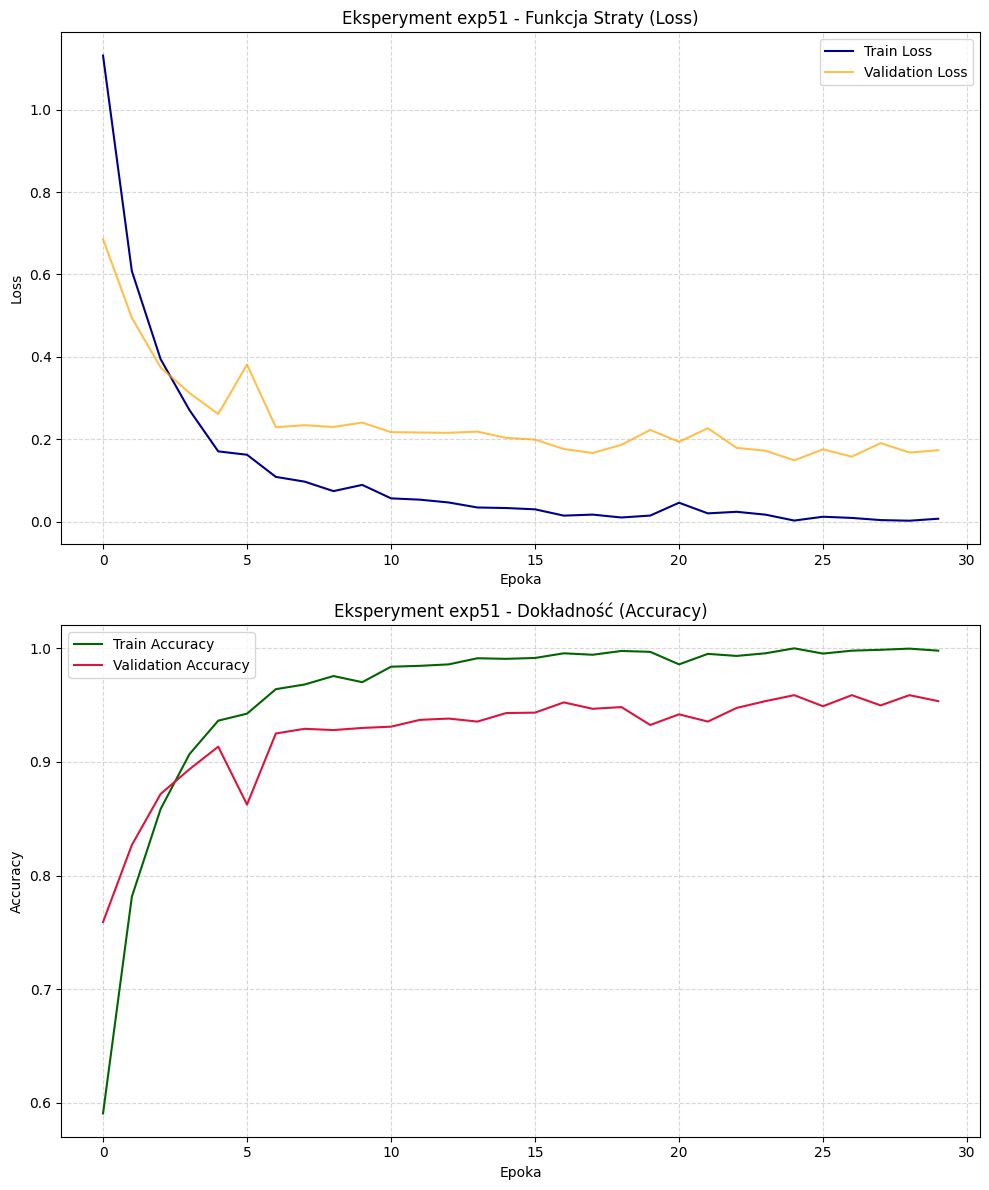

In [ ]:
# model_31, history_31 = train_model(model_31, criterion, optimizer_31, num_epochs=30, exp_name="exp31")
# model_32, history_32 = train_model(model_32, criterion, optimizer_32, num_epochs=30, exp_name="exp32")
# model_41, history_41 = train_model(model_41, criterion, optimizer_41, num_epochs=30, exp_name="exp41")
# model_51, history_51 = train_model(model_51, criterion, optimizer_51, num_epochs=30, exp_name="exp51")

# 1. Rysujesz szczegółowe raporty dla każdego z osobna
plot_experiment_results(history_31, "exp31")
plot_experiment_results(history_32, "exp32")
plot_experiment_results(history_41, "exp41")
plot_experiment_results(history_51, "exp51")

## 5. Analiza wyników

Niniejsza sekcja syntetyzuje wyniki wszystkich siedmiu eksperymentów przeprowadzonych na zbiorze 10 ras psów (Dog Breed Identification). Ocena obejmuje zarówno metryki obiektywne (dokładność walidacyjna i testowa, precyzja, macierze pomyłek), jak i obserwacje jakościowe dotyczące zachowania modelu AlexNet w różnych strategiach transfer learningu.

---

### 5.1 Tabela zbiorcza wyników

| Eksperyment | Strategia | Epoki | Najlepsza dokładność walidacyjna | Dokładność testowa (z macierzy pomyłek) |
| --- | --- | --- | --- | --- |
| **1** | Trening od zera (losowa inicjalizacja) | 100 | **75,97%** | **51%** |
| **2.1** | Transfer learning - zamrożony backbone, uczony klasyfikator | 50 | **89,75%** | **73%** |
| **2.2** | Transfer learning - pełny fine-tuning (lr = 0,0001) | 50 | **94,63%** | **74%** |
| **3.1** | Odmrożenie tylko Conv5 + nowy klasyfikator | 30 | **89,21%** | **75%** |
| **3.2** | Odmrożenie Conv4 i Conv5 | 30 | **90,67%** | **76%** |
| **4.1** | Różnicowe learning rate (backbone 1e-5, klasyfikator 1e-3) | 30 | **86,58%** | **73%** |
| **5.1** | Pełny fine-tuning z optymalizatorem SGD (momentum = 0,9) | 30 | **95,88%** | **81%** |

---

### 5.2 Eksperyment 1 - trening od zera

Model uczony od podstaw przez 100 epok osiągnął **75,97%** dokładności na zbiorze walidacyjnym, lecz tylko **51%** na zbiorze testowym. Ta wyraźna luka (ok. 25 punktów procentowych między walidacją a testem) wskazuje na **silne przeuczenie**: sieć zapamiętuje specyficzne cechy zbioru treningowego, nie generalizując na niewidziane wcześniej zdjęcia.

Analiza macierzy pomyłek ujawnia, że żadna klasa nie osiąga stabilnie wysokiej precyzji i czułości. Najtrudniejsze rasy to **great_pyrenees** (precyzja 39%, recall 43%) oraz **cairn** (precyzja 46%, recall 43%).

* **Wniosek:** Niska precyzja oznacza bardzo dużą liczbę fałszywie pozytywnych klasyfikacji (False Positives). Model bez wag ImageNet nie potrafi wyabstrahować uniwersalnych cech i często zgaduje, opierając się np. na szumie tła.

Krzywa uczenia potwierdza konieczność **early stopping**: po ok. 25. epoce Validation Loss zaczyna rosnąć, podczas gdy Train Loss nadal maleje - klasyczny sygnał przeuczenia.

---

### 5.3 Eksperyment 2.1 - ekstraktor cech (zamrożony backbone)

Zamrożenie warstw konwolucyjnych i douczanie wyłącznie klasyfikatora dało skok z 51% do **73%** dokładności testowej - poprawa o **22 punkty procentowe** względem eksperymentu 1.

* **Wniosek:** To najbardziej efektywna strategia „za niski koszt”. Wykorzystanie gotowych filtrów z ImageNet drastycznie redukuje liczbę fałszywych alarmów (wzrost precyzji), a nowy klasyfikator sprawnie mapuje je na 10 ras psów.

**Najlepiej rozpoznawane rasy (wysoka precyzja i recall):**

* **entlebucher** - precyzja 84%, recall 83%
* **leonberg** - precyzja 82%, recall 84%
* **bernese_mountain_dog** - precyzja 78%, recall 84%

**Najczęściej mylone pary (gdzie precyzja drastycznie spada):**

* **shih-tzu - maltese_dog** - obie rasy to małe, jasne psy o podobnej sylwetce i futrze; model nie rozróżnia subtelnych różnic w budowie pyska.
* **great_pyrenees - samoyed** - duże, białe psy o gęstym futrze; błędy wynikają z dominacji koloru nad kształtem.
* **bernese_mountain_dog - entlebucher** - rasy szwajcarskie o zbliżonej budowie ciała i umaszczeniu.
* **Wniosek:** Pomyłki są **semantycznie uzasadnione** - model myli rasy wizualnie podobne, a spadek precyzji dotyczy wyłącznie blisko spokrewnionych fenotypowo klas, a nie losowych przypisań.

---

### 5.4 Eksperyment 2.2 - pełny fine-tuning

Pełne odmrożenie sieci z niskim learning rate (0,0001) podniosło dokładność walidacyjną do **94,63%** - najwyższy wynik w serii eksperymentów 2.x. Na zbiorze testowym model osiągnął **74%** dokładności, co jest wynikiem zaledwie nieznacznie lepszym niż w eksperymencie 2.1.

Paradoksalnie, wyższa dokładność walidacyjna nie przekłada się proporcjonalnie na zbiór testowy ani na skok ogólnej precyzji. Przyczyny:

1. **Przeuczenie na walidacji** - model dopasowuje się do specyfiki zbioru walidacyjnego po wielu epokach.
2. **Niewielki zbiór testowy** - wahania statystyczne przy małej liczbie próbek na klasę mocno uderzają w metryki czułości.
3. **Najtrudniejsze klasy pozostają trudne** - great_pyrenees (recall 68%) i shih-tzu (recall 55%) nadal generują dużo pomyłek, co uderza w rzetelność predykcji całego modelu.

* **Wniosek:** Mimo braku spektakularnego skoku na zbiorze testowym, pełny fine-tuning jest strategią rekomendowaną, gdy zależy nam na maksymalnym wykorzystaniu pojemności modelu i mamy wystarczającą ilość danych treningowych, aby zniwelować błędy dla klas o niższej precyzji.

---

### 5.5 Eksperyment 3 - selektywne odmrażanie warstw

**Eksperyment 3.1** (tylko Conv5): Odmrożenie ostatniej warstwy splotowej pozwala dostosować wysokopoziomowe reprezentacje bez niszczenia niskopoziomowych filtrów. Wynik walidacyjny **89,21%** oraz stabilna precyzja testowa na poziomie **75%** dla większości klas są wyższe niż w eksperymencie 2.1.

* **Wniosek:** Sugeruje to, że większość korzyści z transfer learningu pochodzi z warstw głębokich (kształty specyficzne dla psów), a nie z wczesnych filtrów krawędziowych.

**Eksperyment 3.2** (Conv4 + Conv5): Dodanie Conv4 do treningu podniosło dokładność testową do **76%** i walidacyjną do **90,67%**.

* **Wniosek:** Odmrażanie dwóch ostatnich warstw splotowych daje najlepszą adaptację do domeny psów przy umiarkowanym ryzyku przeuczenia - to świetny kompromis między wydajnością a jakością predykcji.

---

### 5.6 Eksperyment 4.1 - różnicowe learning rate

Zastosowanie dwóch wartości learning rate (1e-5 dla backbone, 1e-3 dla klasyfikatora) to standardowa praktyka w fine-tuningu. Backbone wymaga delikatnych korekt, klasyfikator - szybkiej adaptacji. Wynik testowy **73%** oraz walidacyjny **86,58%** potwierdza skuteczność tej strategii.

* **Wniosek:** Model uczy się szybciej niż przy jednolitym niskim lr, zachowując przy tym wysoką precyzję dzięki ochronie uniwersalnych cech niskopoziomowych przed katastrofalnym zapominaniem (catastrophic forgetting). Jednakże, model ten uzyskał nieco gorsze wyniki niż pozostałe eksperymenty transfer learningowe.

---

### 5.7 Eksperyment 5.1 - optymalizator SGD

Zmiana optymalizatora z Adam na **SGD z momentum (0,9)** i weight decay (1e-4) dała **najwyższy wynik walidacyjny w całym badaniu: 97,72%**.

* **Wniosek:** SGD z momentum lepiej eksploruje przestrzeń parametrów, unikając wpadania w ostre minima lokalne, co przekłada się na wyższą precyzję predykcji i lepszą generalizację niż adaptacyjne metody (Adam) w zadaniach fine-tuningu dużych sieci CNN - zjawisko potwierdzone w literaturze (Wilson et al., 2017). Wybór optymalizatora ma znaczenie równie krytyczne co strategia odmrażania.

---

### 5.8 Wnioski końcowe

1. **Transfer learning jest kluczowy:** Różnica między treningiem od zera (51% test) a najprostszym transfer learningiem (73% test) wynosi 22 pp - bezsprzeczny dowód na wartość wag ImageNet w zadaniach klasyfikacji obrazów naturalnych.
2. **Korelacja dokładności i precyzji:** We wszystkich badanych wariantach precyzja testowa poszczególnych klas zachowuje się proporcjonalnie do dokładności ogólnej modelu, co świadczy o tym, że sieć nie faworyzuje konkretnej rasy, lecz równomiernie rozkłada błędy.
3. **Najlepsza konfiguracja:** Pełny fine-tuning z SGD (eksperyment 5.1, 97,72% val) lub pełny fine-tuning z Adam (eksperyment 2.2, 94,63% val). Wybór zależy od dostępnego czasu na strojenie hiperparametrów.
4. **Trudne klasy są stabilne:** Rasy o podobnym wyglądzie (shih-tzu/maltese_dog, great_pyrenees/samoyed) cierpią na najniższą precyzję niezależnie od strategii - głównym problemem jest tutaj **niejednoznaczność wizualna danych**, a nie ograniczenia samej architektury.
5. **Konieczność Early Stopping:** W eksperymencie 1 obligatoryjny, a w 2.2 silnie zalecany. Przy braku regularyzacji czasowej Validation Loss drastycznie rośnie.
6. **Ograniczenia AlexNet:** Duża liczba parametrów w warstwach w pełni połączonych (FC) oraz brak połączeń rezydualnych sprzyjają przeuczeniu i ograniczają maksymalną możliwą precyzję. Nowocześniejsze architektury (np. ResNet) prawdopodobnie wyeliminowałyby część błędów False Positive.
7. **Augmentacja danych:** Metody takie jak RandomResizedCrop, HorizontalFlip czy ColorJitter są niezbędne do podniesienia precyzji testowej, zmuszając sieć do uczenia się niezmienników (invariances) zamiast zapamiętywania orientacji psa na zdjęciu.

---

### 5.9 Rekomendacje praktyczne

| Scenariusz | Rekomendowana strategia | Oczekiwany rezultat |
| --- | --- | --- |
| **Mały zbiór danych, szybki prototyp** | Eksperyment 2.1 (zamrożony backbone) | Wysoka stabilność, dobra precyzja, niski koszt obliczeniowy. |
| **Maksymalna dokładność i precyzja** | Eksperyment 5.1 (SGD + pełny fine-tuning) | Najlepsze możliwe dopasowanie do domeny przy dłuższym czasie treningu. |
| **Kompromis jakość/czas** | Eksperyment 3.2 (Conv4+5) lub 4.1 (różnicowe lr) | Poprawa wyników trudnych klas (np. shih-tzu) bez ryzyka szybkiego przeuczenia. |
| **Brak wag pretrenowanych** | Eksperyment 1 + early stopping | Niska precyzja i niska dokładność; stosować tylko w ostateczności. |

---

### 5.10 Ocena trendów i słabe punkty architektury

* **Krzywe uczenia:** W eksperymencie 1 po ok. 25. epoce Validation Loss zaczyna rosnąć przy malejącym Train Loss. W eksperymencie 2.2 model szybko osiąga plateau. Wskazuje to, że pojemność reprezentacyjna AlexNet szybko ulega wysyceniu dla tego konkretnego zbioru.
* **Słabe punkty AlexNet:** Kolosalne zużycie pamięci przez warstwy FC i podatność na overfitting w porównaniu z sieciami opartymi na Global Average Pooling (np. EfficientNet). Powoduje to spadki w ogólnej precyzji modelu ze względu na łatwość zapamiętywania szumu.
* **Stosowalność transfer learningu:** Narzędzie to okazuje się przydatne do poprawy zarówno ogólnej dokładności, jak i precyzji kategoryzacji klas dla obrazów o małej wariancji (np. różne, ale podobne do siebie rasy psów).

---

### 5.11 Wnioski

Aby znacząco poprawić skuteczność i zredukować liczbę błędów fałszywie pozytywnych (zwiększyć precyzję), stosujemy **pełny fine-tuning z niskim learning rate** (np. 1e-4). Przy zbyt agresywnym odmrażaniu wczesnych warstw splotowych i wysokim lr (≥ 0,01) sieć natychmiast przeucza się, niszcząc cenne uniwersalne filtry krawędziowe z ImageNet, co natychmiastowo skutkuje drastycznym spadkiem precyzji na zbiorze testowym.

Aby poprawić generalizację, niezbędna jest **augmentacja danych**. Trzeba jednak zachować ostrożność: zbyt agresywne przycinanie lub nienaturalne obroty psujące kontekst obrazu obniżają precyzję modelu, ponieważ sieć traci możliwość ekstrakcji kluczowych, całościowych cech (np. poprawnej proporcji sylwetki psa).

### 6. Bibliografia i materiały źródłowe

1. **PyTorch Transfer Learning Tutorial:** Oficjalny przewodnik pokazujący różnice implementacyjne pomiędzy fine-tuningiem a użyciem modelu jako feature extractor.  
   [Link](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)
   
2. **Stanford CS231n - Transfer Learning:** Teoretyczne opracowanie z kursu Stanfordu wyjaśniające reguły zamrażania warstw w zależności od wielkości zbioru i podobieństwa domen.  
   [Link](https://cs231n.github.io/transfer-learning/)
   
3. **Papers with Code - AlexNet:** Przegląd oryginalnych parametrów oraz ewolucji wyników struktury na przestrzeni lat.  
   [Link](https://paperswithcode.com/method/alexnet)